# Interpretability in Deep Learning: A Hands-On Tour

---

## What is Interpretability?

Imagine you hire a brilliant consultant who gives you great advice — but can never explain *why*. You'd probably feel uneasy trusting them with high-stakes decisions. Modern machine learning models are exactly like that consultant: often accurate, rarely explainable.

**Interpretability** is the field that asks: *What did the model actually learn? Why did it make this prediction? Is it reasoning the right way, or just exploiting a lucky pattern?*

### Why Does It Matter?

- **Safety**: A self-driving car that works for the wrong reasons will fail in unexpected ways.
- **Fairness**: A loan model might achieve high accuracy by learning a protected attribute (race, gender) as a proxy.
- **Science**: In medicine or biology, we don't just want predictions — we want to *understand* the system.
- **Debugging**: When a model fails, interpretability tools help you figure out *why*.

### The Clever Hans Warning

Clever Hans was a horse in early 20th-century Germany, famous for apparently solving arithmetic problems. Investigators eventually discovered he wasn't calculating — he was reading subtle postural cues from his trainer. He had the right *outputs* for the wrong *reasons*.

Deep learning models do this constantly. **High accuracy ≠ correct reasoning.**

---

## What You'll Learn in This Notebook

| Section | Technique | What It Answers |
|---|---|---|
| 1 | Shortcut Learning | How models cheat |
| 2 | LIME | Why did THIS prediction happen? |
| 3 | SHAP | Which features matter globally? |
| 4 | Grad-CAM | Where did the CNN look? |
| 5 | Integrated Gradients | Which pixels contributed? |
| 6 | Probing Classifiers | What concepts are encoded? |
| 7 | Attention | How does a Transformer route information? |
| Final | Challenge | Full interpretability investigation |

**Prerequisites**: Python, basic ML (train/test, sklearn), familiarity with neural networks at the conceptual level.

Let's dig in.

In [1]:
# Install all required packages (run once)
# If you're on Colab or a fresh environment, uncomment the line below:
!pip install shap lime torch torchvision matplotlib seaborn scikit-learn numpy pandas captum --quiet

In [2]:
# ── Core scientific stack ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.colors import Normalize

# ── Sklearn ────────────────────────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.manifold import TSNE
from sklearn.neural_network import MLPClassifier

# ── LIME & SHAP ────────────────────────────────────────────────────────────
import lime
import lime.lime_tabular
import shap

# ── PyTorch ────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ── Reproducibility ────────────────────────────────────────────────────────
np.random.seed(42)
torch.manual_seed(42)

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
CMAP = 'RdBu_r'

print('All imports successful!')
print(f'PyTorch version: {torch.__version__}')

All imports successful!
PyTorch version: 2.10.0


---
# Section 1 — Shortcut Learning: The Clever Hans Problem

## The Core Idea

Models learn to minimize loss on *training data*. If there's a feature in the training data that perfectly predicts the label but is meaningless in the real world, the model will happily use it. This is called **shortcut learning** (also called **Clever Hans behavior** or **spurious correlations**).

**Real-world examples:**
- A pneumonia classifier that learned to predict *lower* risk for asthma patients — because asthma patients always went to the ICU and got aggressive treatment (so they had better outcomes in the training data).
- A cow vs. camel classifier that actually learned to detect *grass vs. sand* backgrounds.
- COVID X-ray classifiers that learned hospital-specific metadata (scanner type, patient position) instead of actual pathology.

## What We'll Do

We'll create a synthetic dataset with:
- 2 real signal features (genuinely predictive)
- 3 noise features (random, not predictive)
- 1 spurious feature (perfectly correlated with `y` in training, but random at test time)

Then we'll train a logistic regression and watch it get fooled.

> **💡 Key Insight**: A model that achieves 100% training accuracy isn't necessarily learning the right thing. Interpretability tools help us audit *what* was learned.


In [3]:
# ── Build synthetic dataset ────────────────────────────────────────────────
np.random.seed(42)
N = 1000

# Real signal features: drawn from different distributions per class
y = np.random.randint(0, 2, size=N)           # binary labels
X_signal = np.column_stack([
    np.random.randn(N) + y * 1.5,             # feature 0: shifted by label
    np.random.randn(N) + y * 1.0,             # feature 1: smaller shift
])

# Noise features: completely random, independent of y
X_noise = np.random.randn(N, 3)               # features 2,3,4

# Spurious feature: nearly perfectly correlated with y (99% match in train)
# We'll flip it at test time to expose the shortcut
spurious_train = y.copy().astype(float) + np.random.randn(N) * 0.01
spurious_test  = np.random.randn(N)           # pure noise at test time

X_all_train = np.column_stack([X_signal, X_noise, spurious_train])
X_all_test  = np.column_stack([X_signal, X_noise, spurious_test])

# Train/test split (indices only, keeping our custom spurious feature)
idx = np.arange(N)
np.random.shuffle(idx)
train_idx, test_idx = idx[:700], idx[700:]

X_train = X_all_train[train_idx]
X_test  = X_all_test[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

feature_names = ['signal_1', 'signal_2', 'noise_1', 'noise_2', 'noise_3', 'spurious']
print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')
print(f'Features: {feature_names}')

Train size: 700, Test size: 300
Features: ['signal_1', 'signal_2', 'noise_1', 'noise_2', 'noise_3', 'spurious']


In [4]:
# ── Train logistic regression ──────────────────────────────────────────────
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc  = accuracy_score(y_test,  clf.predict(X_test))

print(f'Train accuracy: {train_acc:.3f}   <-- suspiciously high!')
print(f'Test  accuracy: {test_acc:.3f}    <-- dropped because spurious feature is now random')
print()

# ── Inspect coefficients ───────────────────────────────────────────────────
coefs = pd.Series(np.abs(clf.coef_[0]), index=feature_names).sort_values(ascending=False)
print('Coefficient magnitudes (absolute value):')
print(coefs.to_string())
print()
print('>>> The SPURIOUS feature has the largest coefficient!')
print('>>> The model learned the shortcut instead of the real signal.')

Train accuracy: 1.000   <-- suspiciously high!
Test  accuracy: 0.507    <-- dropped because spurious feature is now random

Coefficient magnitudes (absolute value):
spurious    6.968088
signal_1    0.703761
signal_2    0.492522
noise_3     0.026005
noise_2     0.011479
noise_1     0.001194

>>> The SPURIOUS feature has the largest coefficient!
>>> The model learned the shortcut instead of the real signal.


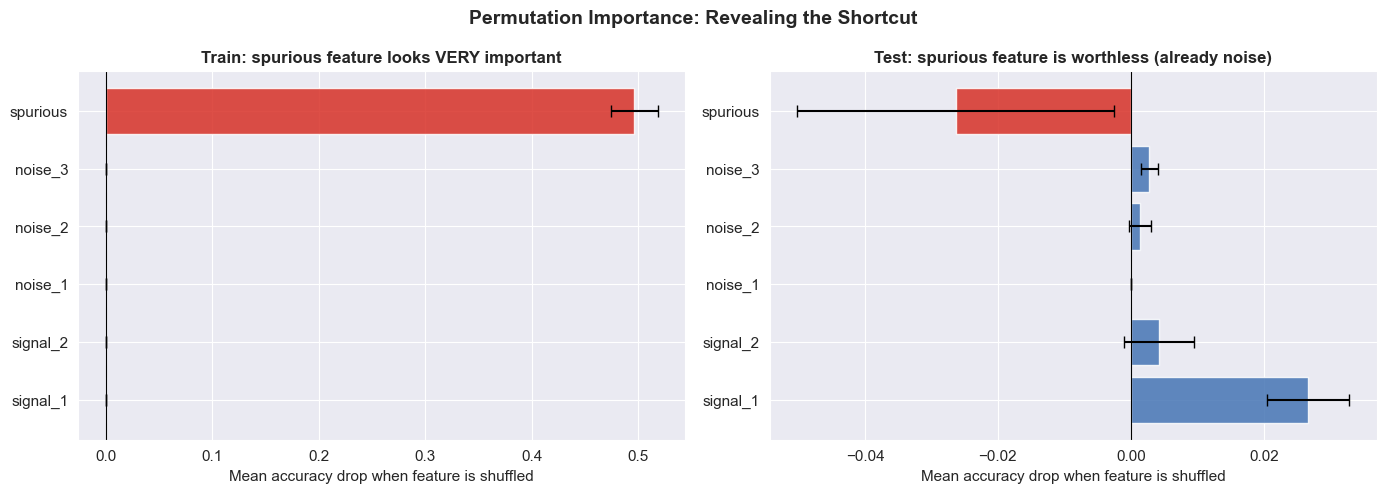


On training data, the spurious feature looks crucial.
On test data, it contributes nothing — exposing the shortcut.


In [5]:
# ── Permutation Importance: confirms the shortcut ──────────────────────────
# Permutation importance measures how much test accuracy DROPS when
# you randomly shuffle a feature (breaking its relationship with y).
# On test data, the spurious feature is already random — so shuffling it
# should matter very little. Let's check train vs test.

perm_train = permutation_importance(clf, X_train, y_train, n_repeats=30, random_state=42)
perm_test  = permutation_importance(clf, X_test,  y_test,  n_repeats=30, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, perm, split in zip(axes, [perm_train, perm_test], ['Train', 'Test']):
    means = perm.importances_mean
    stds  = perm.importances_std
    colors = ['#d73027' if n == 'spurious' else '#4575b4' for n in feature_names]
    bars = ax.barh(feature_names, means, xerr=stds, color=colors, alpha=0.85, capsize=4)
    ax.set_title(f'Permutation Importance ({split} set)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mean accuracy drop when feature is shuffled')
    ax.axvline(0, color='black', linewidth=0.8)

axes[0].set_title('Train: spurious feature looks VERY important', fontsize=12, fontweight='bold')
axes[1].set_title('Test: spurious feature is worthless (already noise)', fontsize=12, fontweight='bold')

fig.suptitle('Permutation Importance: Revealing the Shortcut', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nOn training data, the spurious feature looks crucial.')
print('On test data, it contributes nothing — exposing the shortcut.')

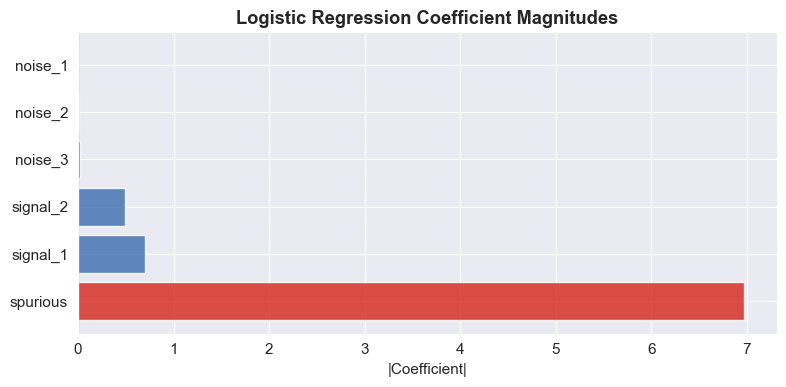

In [6]:
# ── Coefficient bar chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d73027' if n == 'spurious' else '#4575b4' for n in coefs.index]
ax.barh(coefs.index, coefs.values, color=colors, alpha=0.85)
ax.set_xlabel('|Coefficient|')
ax.set_title('Logistic Regression Coefficient Magnitudes', fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

> **⚠️ Watch Out**: Permutation importance on *training* data can be misleading for overfitted models. Always verify on a held-out test set. The gap between train and test importance is itself a signal of a shortcut.

---

## 🏋️ Exercise

1. **Remove the spurious feature** entirely and retrain. What happens to train and test accuracy? Do the coefficients look healthier now?

2. **Weaken the shortcut**: Instead of 99% correlation, make the spurious feature only 80% correlated with `y` in training (hint: increase the noise: `spurious_train = y + np.random.randn(N) * X` — what value of X gives ~80%?). How does this affect the model's behavior?

3. **Bonus**: What if you had *no* signal features at all — just noise and one spurious feature? What would the test accuracy be, and why?

```python
# Starter code for exercise 1
X_train_no_spurious = X_train[:, :5]   # drop the last column
X_test_no_spurious  = X_test[:, :5]
# ... train and evaluate ...
```

---
# Section 2 — LIME: Local Explanations

## The Big Idea

Global model interpretation is hard — complex models carve out decision boundaries in ways that are difficult to summarize globally. But **locally**, near any single prediction, even a complex model can often be approximated by something simple.

**LIME** (Local Interpretable Model-agnostic Explanations, Ribeiro et al. 2016) exploits this:

1. Take a single prediction you want to explain.
2. Create many slightly perturbed versions of that input.
3. Run them through the black-box model to get predictions.
4. Fit a **simple linear model** (interpretable) on this synthetic neighborhood, weighted by distance to the original point.
5. The linear model's coefficients are your explanation.

**Analogy**: You can't describe the entire topography of a mountain range, but you can say "right where you're standing, the ground slopes slightly north-east."

> **💡 Key Insight**: LIME explanations are *local* — they explain a single prediction, not the model's overall behavior. Two nearby points can have very different LIME explanations if the decision boundary is complex in that region.

> **⚠️ Watch Out**: LIME explanations are **approximate**. The quality of the explanation depends on how well a linear model can approximate the local behavior. For highly non-linear boundaries, LIME can be misleading.


In [7]:
# ── Load breast cancer dataset & train a black-box RF ─────────────────────
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
feat_names_bc = bc.feature_names
class_names_bc = bc.target_names  # ['malignant', 'benign']

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_bc_train, y_bc_train)

rf_test_acc = accuracy_score(y_bc_test, rf.predict(X_bc_test))
print(f'Random Forest test accuracy: {rf_test_acc:.4f}')
print(f'Dataset: {X_bc.shape[0]} samples, {X_bc.shape[1]} features')
print(f'Classes: {class_names_bc}')

Random Forest test accuracy: 0.9561
Dataset: 569 samples, 30 features
Classes: ['malignant' 'benign']


In [8]:
# ── Set up LIME explainer ─────────────────────────────────────────────────
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_bc_train,
    feature_names=feat_names_bc,
    class_names=class_names_bc,
    mode='classification',
    random_state=42
)

# ── Explain 3 specific predictions ────────────────────────────────────────
# We'll pick: one confident correct benign, one confident correct malignant,
# and one that the model got wrong.

preds = rf.predict(X_bc_test)
probs = rf.predict_proba(X_bc_test)

# Find interesting samples
correct_benign   = np.where((preds == 1) & (y_bc_test == 1) & (probs[:,1] > 0.95))[0]
correct_malig    = np.where((preds == 0) & (y_bc_test == 0) & (probs[:,0] > 0.90))[0]
wrong_preds      = np.where(preds != y_bc_test)[0]

sample_ids = [correct_benign[0], correct_malig[0], wrong_preds[0] if len(wrong_preds) > 0 else correct_benign[1]]
sample_labels = ['Correct: Benign', 'Correct: Malignant', 'Incorrect prediction' if len(wrong_preds) > 0 else 'Correct: Benign (2)']

print(f'Selected samples: indices {sample_ids}')
for i, sid in enumerate(sample_ids):
    true_cls  = class_names_bc[y_bc_test[sid]]
    pred_cls  = class_names_bc[preds[sid]]
    conf      = probs[sid].max()
    print(f'  Sample {sid}: True={true_cls}, Pred={pred_cls}, Confidence={conf:.3f}  [{sample_labels[i]}]')

Selected samples: indices [np.int64(1), np.int64(0), np.int64(3)]
  Sample 1: True=benign, Pred=benign, Confidence=1.000  [Correct: Benign]
  Sample 0: True=malignant, Pred=malignant, Confidence=1.000  [Correct: Malignant]
  Sample 3: True=benign, Pred=malignant, Confidence=0.720  [Incorrect prediction]


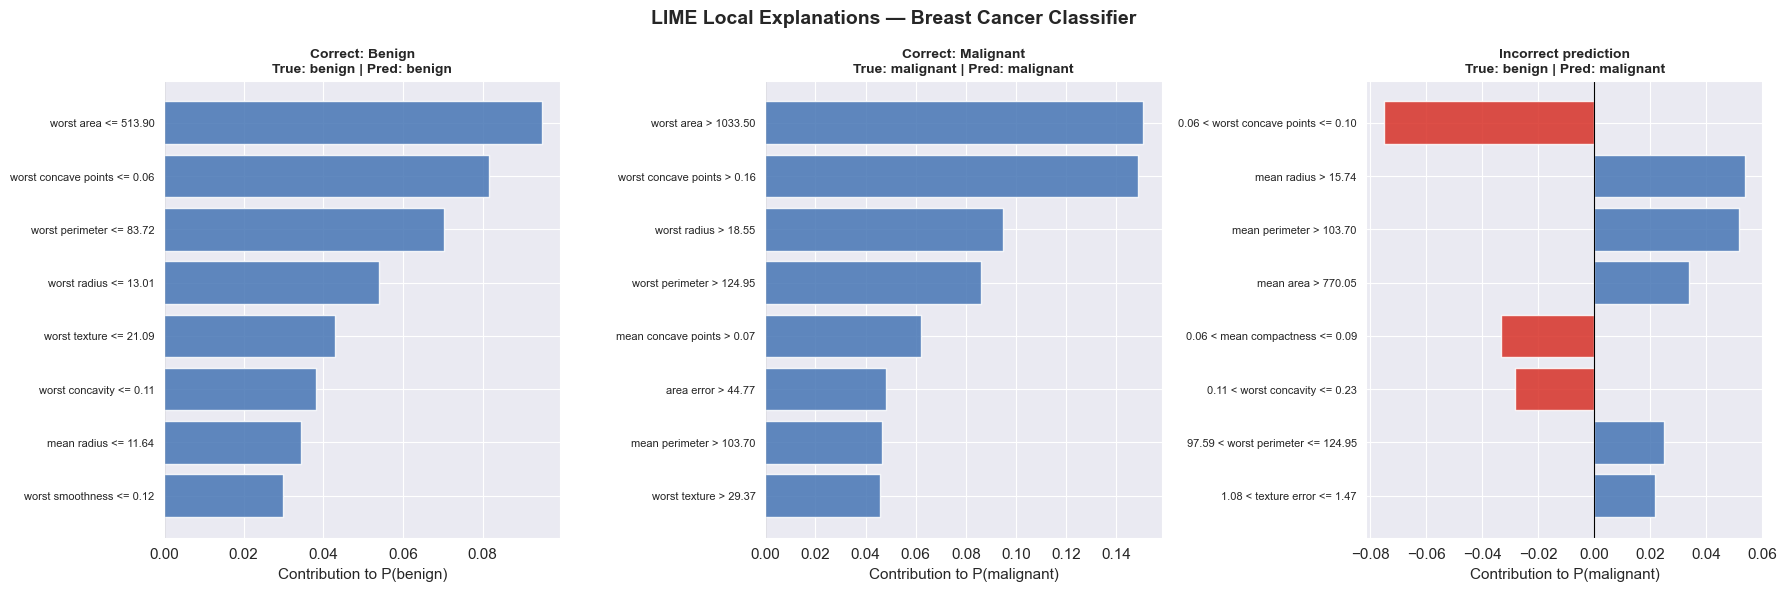

Blue = pushes toward predicted class | Red = pushes against predicted class


In [9]:
# ── Generate and plot LIME explanations ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax_idx, (sid, label) in enumerate(zip(sample_ids, sample_labels)):
    # Generate LIME explanation — pass labels=(0,1) so both classes are stored
    exp = explainer_lime.explain_instance(
        data_row=X_bc_test[sid],
        predict_fn=rf.predict_proba,
        num_features=8,
        num_samples=1000,
        labels=(0, 1)          # fix: explicitly compute both class explanations
    )

    # Extract feature contributions for the predicted class
    pred_class = int(preds[sid])   # fix: cast np.int64 → int so dict lookup works
    explanation_list = exp.as_list(label=pred_class)
    feat_labels = [e[0] for e in explanation_list]
    feat_values = [e[1] for e in explanation_list]

    # Sort by absolute value
    sorted_pairs = sorted(zip(feat_labels, feat_values), key=lambda x: abs(x[1]))
    feat_labels_s = [p[0] for p in sorted_pairs]
    feat_values_s = [p[1] for p in sorted_pairs]

    colors = ['#d73027' if v < 0 else '#4575b4' for v in feat_values_s]
    ax = axes[ax_idx]
    ax.barh(range(len(feat_labels_s)), feat_values_s, color=colors, alpha=0.85)
    ax.set_yticks(range(len(feat_labels_s)))
    ax.set_yticklabels(feat_labels_s, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    true_cls = class_names_bc[y_bc_test[sid]]
    pred_cls = class_names_bc[preds[sid]]
    ax.set_title(f'{label}\nTrue: {true_cls} | Pred: {pred_cls}', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'Contribution to P({pred_cls})')

fig.suptitle('LIME Local Explanations — Breast Cancer Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Blue = pushes toward predicted class | Red = pushes against predicted class')

## 🏋️ Exercise

1. **Wrong prediction investigation**: Find the sample the model predicted incorrectly. Look at its LIME explanation. Do the features highlighted suggest why the model was confused? Does the local explanation make sense given what you know about breast cancer features (radius, texture, smoothness...)?

2. **Same-class comparison**: Find two samples that are both correctly classified as *benign*. Generate LIME explanations for both. Are the explanations similar (same features highlighted, same direction)? What does this tell you about how locally consistent the model is?

3. **Stability check**: Run LIME on the same sample three times with different `num_samples` (100, 500, 5000). How stable are the explanations? Does the ranking of features change?

```python
# Starter: find all misclassified samples
misclassified = np.where(preds != y_bc_test)[0]
print(f'Misclassified: {len(misclassified)} samples')
# Now explain each one with LIME...
```

---
# Section 3 — SHAP: Principled Attribution

## From Local to Global

LIME explains individual predictions, but what if you want to understand the model's behavior *across the whole dataset*? SHAP (SHapley Additive exPlanations, Lundberg & Lee 2017) provides exactly this.

SHAP is grounded in **cooperative game theory**. The core idea:

> *How much does each feature contribute to pushing the prediction away from the average?*

This is measured using **Shapley values**, which fairly allocate credit among features by averaging over all possible orderings in which features could be introduced. They have nice mathematical properties:
- **Efficiency**: attributions sum to the difference between the prediction and the baseline
- **Symmetry**: equal features get equal credit
- **Null player**: features that don't affect the output get zero attribution

**For tree models** (Random Forests, XGBoost), SHAP can be computed exactly and efficiently using the TreeExplainer.

> **💡 Key Insight**: SHAP values decompose any prediction as:
> `prediction = base_value + SHAP(feature_1) + SHAP(feature_2) + ...`
> This additive decomposition is exact (not an approximation like LIME).

> **⚠️ Watch Out**: SHAP values tell you about feature contributions *within this model*. They don't tell you about causal importance in the real world — a feature can have high SHAP because it's correlated with another important feature.

## Reading the Plots

We'll generate three kinds of SHAP plots:

**Waterfall plot** (single prediction): Shows how each feature pushes the prediction up or down from the base value.

**Beeswarm plot** (whole dataset): Each dot is one sample. Color = feature value, x-position = SHAP value. Reveals how feature values relate to their impact.

**Bar plot** (mean |SHAP|): Global feature importance — average absolute SHAP value per feature.


In [10]:
# ── SHAP with TreeExplainer ────────────────────────────────────────────────
# We reuse the Random Forest trained in Section 2

shap.initjs()  # initialize JavaScript for interactive plots (works in Jupyter)

# TreeExplainer computes exact SHAP values for tree-based models
explainer_shap = shap.TreeExplainer(rf)

# Compute SHAP values for the test set
# shap_values shape: (n_samples, n_features, n_classes) for classifiers
shap_values = explainer_shap(X_bc_test)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Base value (average prediction): {explainer_shap.expected_value}')

# For binary classification, we'll use class 1 (benign) SHAP values
# shap_values[:, :, 1] selects class=1 contributions
shap_vals_class1 = shap_values[:, :, 1]

SHAP values shape: (114, 30, 2)
Base value (average prediction): [0.37551648 0.62448352]


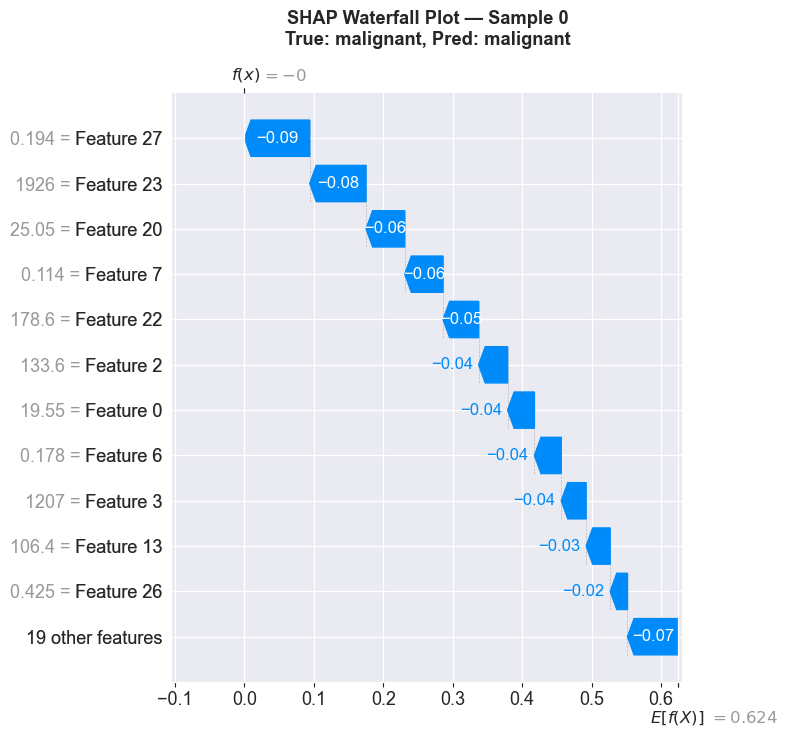


How to read: Each bar shows how much that feature pushed the prediction
up (blue) or down (red) from the base value (average model output).
Base value = 0.624, Final prediction sum shown at top.


In [11]:
# ── (a) Waterfall plot: explain one prediction ─────────────────────────────
# Pick the first test sample for demonstration
sample_idx = 0

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_vals_class1[sample_idx], max_display=12, show=False)
plt.title(f'SHAP Waterfall Plot — Sample {sample_idx}\n'
          f'True: {class_names_bc[y_bc_test[sample_idx]]}, '
          f'Pred: {class_names_bc[rf.predict(X_bc_test[[sample_idx]])[0]]}',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print('\nHow to read: Each bar shows how much that feature pushed the prediction')
print('up (blue) or down (red) from the base value (average model output).')
print(f'Base value = {explainer_shap.expected_value[1]:.3f}, Final prediction sum shown at top.')

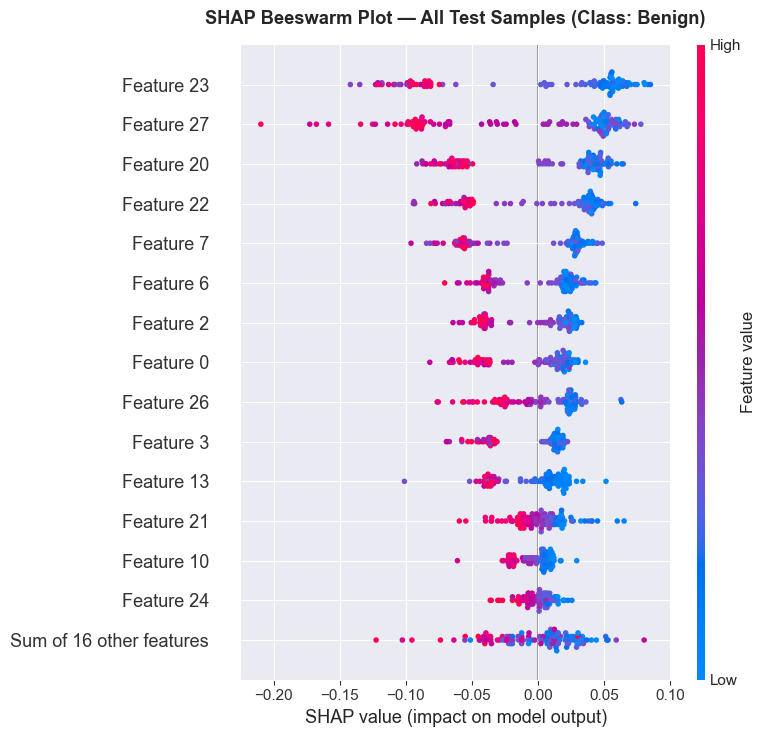


How to read:
  • Each dot = one test sample
  • X-position = SHAP value (impact on prediction)
  • Color = feature value (red=high, blue=low)
  • Features sorted by mean |SHAP| (most important at top)
  • E.g., if high "worst radius" (red) → large negative SHAP → pushes toward malignant


In [12]:
# ── (b) Beeswarm plot: global overview of all test samples ─────────────────
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_vals_class1, max_display=15, show=False)
plt.title('SHAP Beeswarm Plot — All Test Samples (Class: Benign)', 
          fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print('\nHow to read:')
print('  • Each dot = one test sample')
print('  • X-position = SHAP value (impact on prediction)')
print('  • Color = feature value (red=high, blue=low)')
print('  • Features sorted by mean |SHAP| (most important at top)')
print('  • E.g., if high "worst radius" (red) → large negative SHAP → pushes toward malignant')

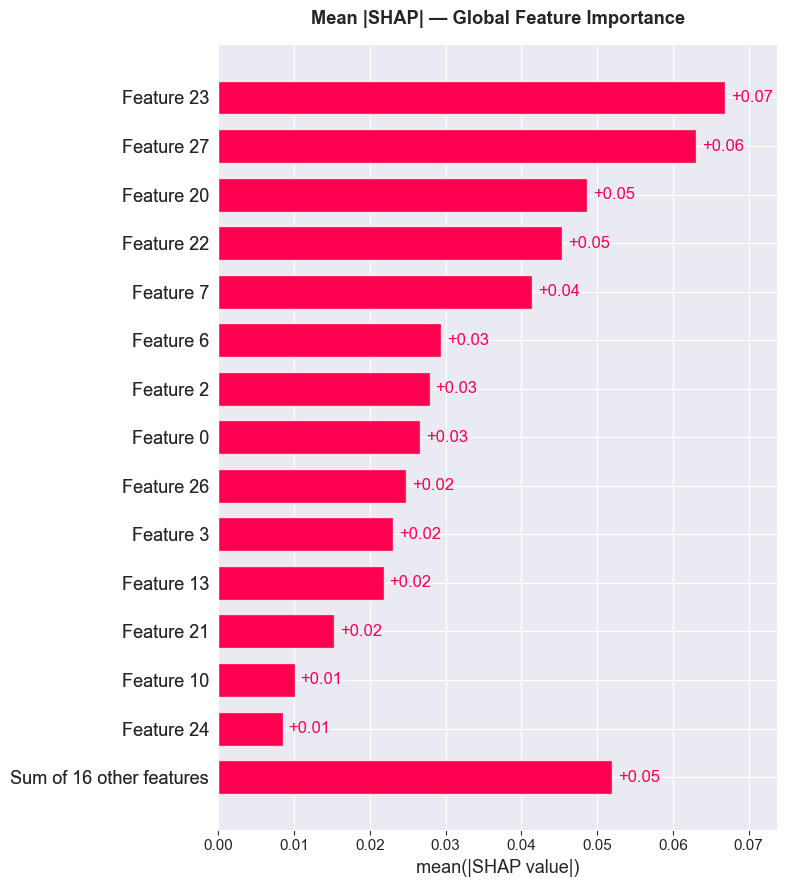


How to read: mean(|SHAP value|) over all test samples.
This gives a simple ranking of which features the model relies on most.


In [13]:
# ── (c) Bar plot: mean absolute SHAP values ────────────────────────────────
plt.figure(figsize=(8, 7))
shap.plots.bar(shap_vals_class1, max_display=15, show=False)
plt.title('Mean |SHAP| — Global Feature Importance', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print('\nHow to read: mean(|SHAP value|) over all test samples.')
print('This gives a simple ranking of which features the model relies on most.')

## 🏋️ Exercise

1. **Feature reduction**: Look at the SHAP bar plot. Identify the top 3 features by mean |SHAP|. Now train a new Random Forest using *only* those 3 features. How much accuracy do you lose compared to the full model? What does this tell you about feature redundancy in this dataset?

2. **SHAP interaction**: In the beeswarm plot, notice that some features have a mix of red and blue dots on both sides of zero. What does this mean? Can you find a feature where high values consistently push toward one class?

3. **LIME vs SHAP**: For the same misclassified sample you found in Section 2, compare the LIME explanation and the SHAP waterfall plot. Do they agree on which features are most important? Where do they disagree, and why might that be?

```python
# Starter: top-3 feature model
# Get feature importances from SHAP
mean_abs_shap = np.abs(shap_vals_class1.values).mean(axis=0)
top3_idx = np.argsort(mean_abs_shap)[-3:]
top3_names = [feat_names_bc[i] for i in top3_idx]
print('Top 3 features:', top3_names)

# Train with only top 3
rf_top3 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_top3.fit(X_bc_train[:, top3_idx], y_bc_train)
acc_top3 = accuracy_score(y_bc_test, rf_top3.predict(X_bc_test[:, top3_idx]))
print(f'Top-3 model accuracy: {acc_top3:.4f} vs full model: {rf_test_acc:.4f}')
```

---
# Section 4 — Grad-CAM: Where Did the Network Look?

## Interpretability for CNNs

LIME and SHAP work on tabular data, but what about images? For convolutional neural networks, we want to know: **which regions of the image were most influential for the prediction?**

**Grad-CAM** (Gradient-weighted Class Activation Mapping, Selvaraju et al. 2017) answers this by combining two pieces of information:

1. **Activations** from the last convolutional layer — these encode *where* the network detected features.
2. **Gradients** of the class score with respect to those activations — these encode *how important* each spatial location is for the final decision.

The algorithm:
1. Forward pass → capture activations at last conv layer
2. Backward pass for target class → capture gradients at last conv layer
3. Global average pool the gradients → importance weights per channel
4. Weighted sum of activations → coarse localization map
5. Apply ReLU (we only care about positive contributions)
6. Upsample to input size and overlay

**Analogy**: Imagine the conv layer is a team of detectives, each specializing in a different visual pattern. Grad-CAM asks: *which detectives mattered most for this verdict, and where were they looking?*

> **💡 Key Insight**: We implement Grad-CAM from scratch using PyTorch hooks — this is more educational than using a library and shows you exactly what's happening under the hood.

> **⚠️ Watch Out**: Grad-CAM highlights regions at the resolution of the last conv feature map — which is coarser than the input image. For pixel-level precision, use Integrated Gradients (Section 5).


In [14]:
# ── CNN architecture for MNIST ─────────────────────────────────────────────
class MNISTNet(nn.Module):
    """Simple 2-layer CNN for MNIST. Designed to be fast (3 epochs ~ 30s)."""
    def __init__(self):
        super().__init__()
        # Conv block 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 28x28 -> 28x28
        self.pool1 = nn.MaxPool2d(2)                               # 28x28 -> 14x14
        # Conv block 2 (Grad-CAM will hook here)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 14x14 -> 14x14
        self.pool2 = nn.MaxPool2d(2)                               # 14x14 -> 7x7
        # Classifier head
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))  # shape: (B, 64, 14, 14)
        x = self.pool2(x)          # shape: (B, 64, 7, 7)
        x = x.view(x.size(0), -1) # flatten: (B, 64*7*7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ── Data loading ───────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST(root='/tmp/mnist', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='/tmp/mnist', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=0)

print(f'Train: {len(train_dataset)} samples | Test: {len(test_dataset)} samples')

Train: 60000 samples | Test: 10000 samples


In [15]:
# ── Training loop (3 epochs, ~30 seconds on CPU) ───────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = MNISTNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, 4):  # 3 epochs
    model.train()
    total_loss = 0
    correct = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch_x)
        correct += (output.argmax(1) == batch_y).sum().item()
    
    train_acc_epoch = correct / len(train_dataset)
    print(f'Epoch {epoch}/3 | Loss: {total_loss/len(train_dataset):.4f} | Train Acc: {train_acc_epoch:.4f}')

# ── Test accuracy ──────────────────────────────────────────────────────────
model.eval()
correct = 0
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        correct += (model(batch_x).argmax(1) == batch_y).sum().item()
print(f'\nTest Accuracy: {correct / len(test_dataset):.4f}')

Using device: cpu
Epoch 1/3 | Loss: 0.2317 | Train Acc: 0.9332
Epoch 2/3 | Loss: 0.0564 | Train Acc: 0.9830
Epoch 3/3 | Loss: 0.0382 | Train Acc: 0.9881

Test Accuracy: 0.9879


In [16]:
# ── Grad-CAM Implementation from Scratch ──────────────────────────────────

class GradCAM:
    """
    Grad-CAM implementation using PyTorch forward and backward hooks.
    
    How it works:
    1. Forward hook: saves the activation maps from the target layer.
    2. Backward hook: saves the gradients flowing back through that layer.
    3. compute_cam(): combines them into a localization map.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
        # Register hooks
        self._fwd_hook = target_layer.register_forward_hook(self._save_activation)
        self._bwd_hook = target_layer.register_full_backward_hook(self._save_gradient)
    
    def _save_activation(self, module, input, output):
        """Called automatically during forward pass."""
        self.activations = output.detach()  # shape: (B, C, H, W)
    
    def _save_gradient(self, module, grad_input, grad_output):
        """Called automatically during backward pass."""
        self.gradients = grad_output[0].detach()  # shape: (B, C, H, W)
    
    def compute_cam(self, input_tensor, class_idx=None):
        """
        Compute Grad-CAM heatmap for a given input and target class.
        
        Args:
            input_tensor: (1, C, H, W) — single image
            class_idx: target class index (None = predicted class)
        Returns:
            cam: (H_in, W_in) normalized heatmap in [0, 1]
            predicted_class: int
        """
        self.model.eval()
        
        # Forward pass
        output = self.model(input_tensor)  # (1, num_classes)
        predicted_class = output.argmax(dim=1).item()
        
        if class_idx is None:
            class_idx = predicted_class
        
        # Backward pass: compute gradients of the target class score
        self.model.zero_grad()
        score = output[0, class_idx]   # scalar score for target class
        score.backward()
        
        # Step 3: Global average pool the gradients -> importance weights per channel
        # gradients shape: (1, C, H, W); take mean over spatial dims H, W
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        
        # Step 4: Weighted sum of activation channels
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)
        
        # Step 5: ReLU — we only care about positive contributions
        cam = F.relu(cam)
        
        # Step 6: Upsample to input image size
        H_in = input_tensor.shape[2]
        W_in = input_tensor.shape[3]
        cam = F.interpolate(cam, size=(H_in, W_in), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()   # (H_in, W_in)
        
        # Normalize to [0, 1]
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        
        return cam, predicted_class
    
    def remove_hooks(self):
        """Clean up hooks when done."""
        self._fwd_hook.remove()
        self._bwd_hook.remove()

# Create GradCAM instance targeting the LAST conv layer (conv2)
grad_cam = GradCAM(model, target_layer=model.conv2)
print('GradCAM ready. Targeting: model.conv2 (last convolutional layer)')

GradCAM ready. Targeting: model.conv2 (last convolutional layer)


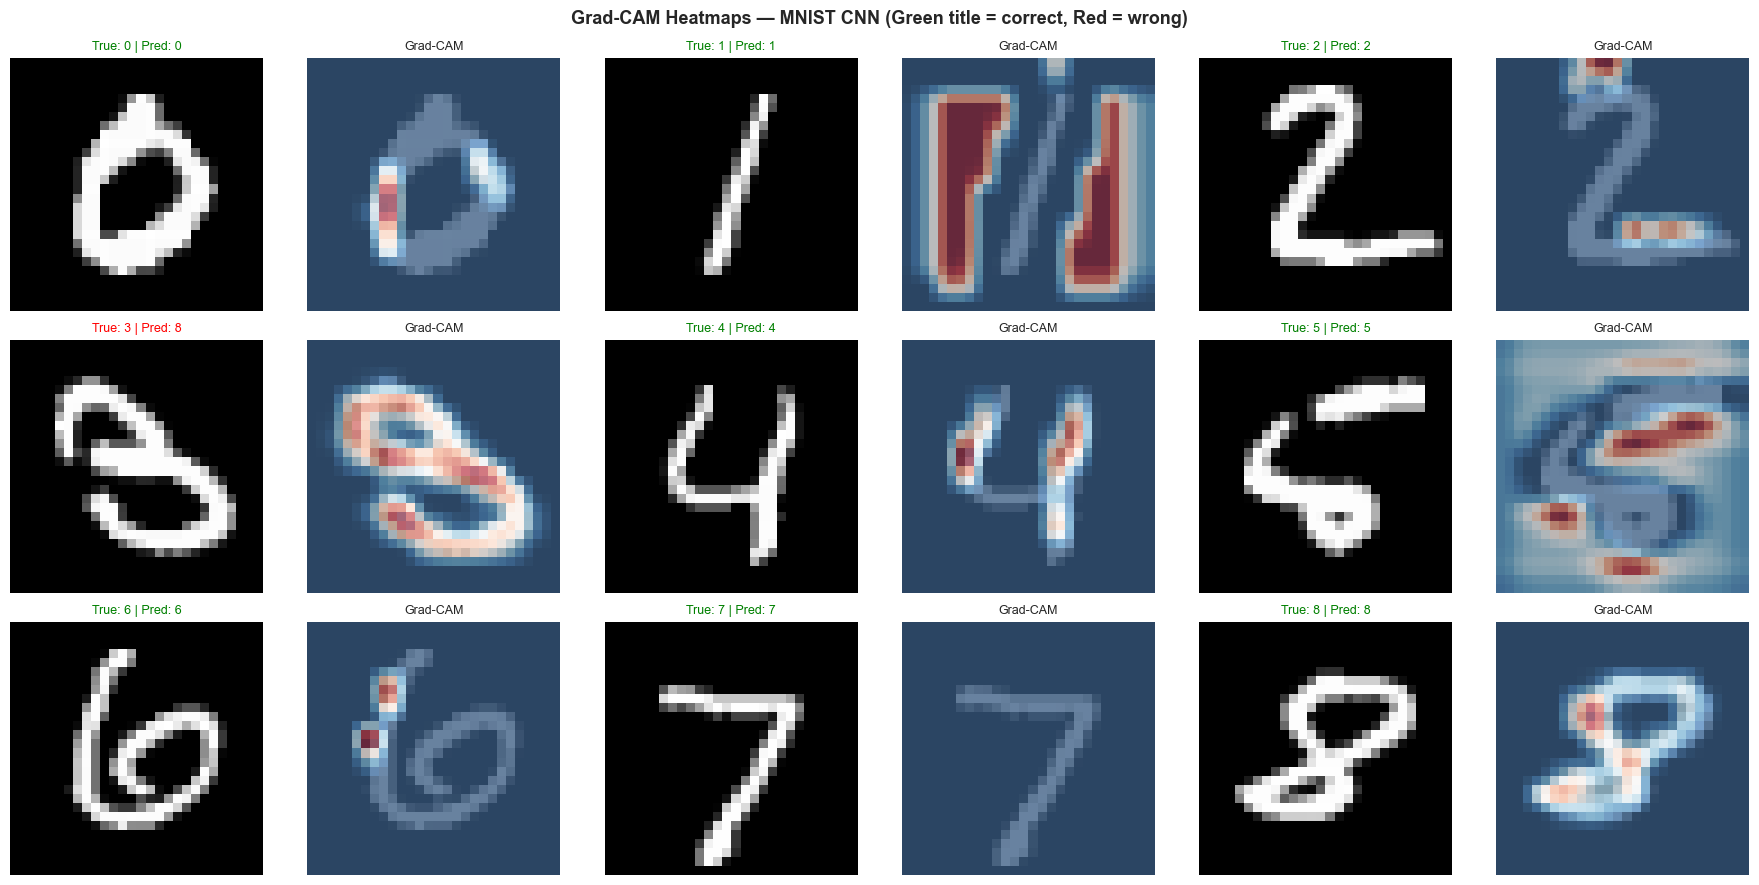

Warm colors (red/yellow) = regions the network focused on for its prediction.


In [17]:
# ── Visualize Grad-CAM on a 3x3 grid of test images ───────────────────────
# Get a batch of test images
test_images, test_labels = next(iter(test_loader))
test_images_dev = test_images.to(device)

# Pick 9 samples: one from each digit class 0-8
selected = []
for digit in range(9):
    idxs = (test_labels == digit).nonzero(as_tuple=True)[0]
    selected.append(idxs[0].item())

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
# Left column of each pair: original | Right column: heatmap overlay

for plot_idx, img_idx in enumerate(selected):
    row = plot_idx // 3
    col = (plot_idx % 3) * 2  # 0,2,4 for originals; 1,3,5 for overlays
    
    img_tensor = test_images_dev[img_idx:img_idx+1]  # (1, 1, 28, 28)
    img_np = test_images[img_idx].squeeze().numpy()   # (28, 28) for display
    true_label = test_labels[img_idx].item()
    
    cam, pred_class = grad_cam.compute_cam(img_tensor)
    
    # Original image
    ax_orig = axes[row, col]
    ax_orig.imshow(img_np, cmap='gray', interpolation='nearest')
    ax_orig.set_title(f'True: {true_label} | Pred: {pred_class}', fontsize=9,
                      color='green' if true_label == pred_class else 'red')
    ax_orig.axis('off')
    
    # Grad-CAM overlay
    ax_cam = axes[row, col+1]
    # Normalize image to [0,1] for display
    img_disp = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    ax_cam.imshow(img_disp, cmap='gray', alpha=0.6, interpolation='nearest')
    ax_cam.imshow(cam, cmap=CMAP, alpha=0.6, interpolation='nearest')
    ax_cam.set_title('Grad-CAM', fontsize=9)
    ax_cam.axis('off')

fig.suptitle('Grad-CAM Heatmaps — MNIST CNN (Green title = correct, Red = wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Warm colors (red/yellow) = regions the network focused on for its prediction.')

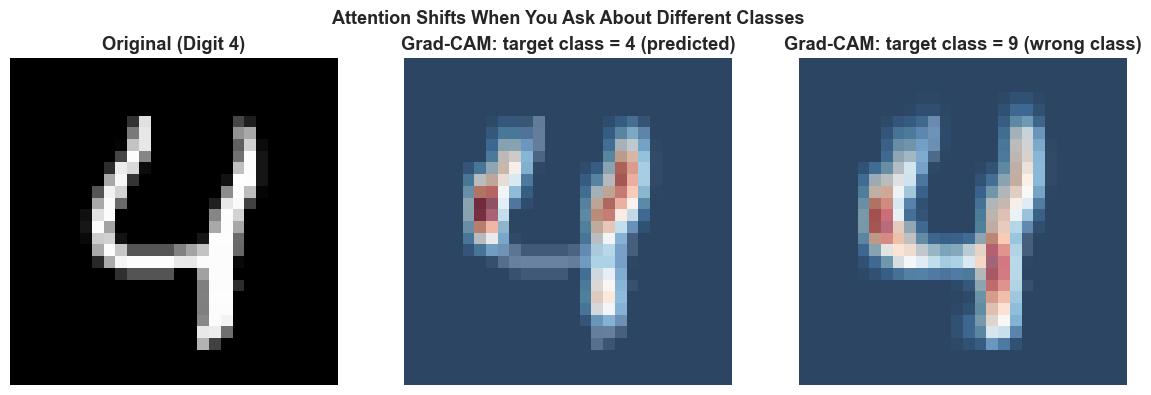

Notice: the heatmap shifts to different regions depending on which class you target.
Class 4 focuses on the open top; class 9 might focus on the curved bottom.


In [18]:
# ── Grad-CAM for a WRONG class: comparing class targets ───────────────────
# For the same image, compare Grad-CAM for the PREDICTED class vs. a WRONG class.
# This shows how the network's attention shifts depending on what class you ask about.

# Use digit 4 image for demonstration
target_digit = 4
idxs_4 = (test_labels == target_digit).nonzero(as_tuple=True)[0]
demo_idx = idxs_4[0].item()

img_tensor = test_images_dev[demo_idx:demo_idx+1]
img_np = test_images[demo_idx].squeeze().numpy()
img_disp = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

# Compute CAM for predicted class (4) and a confusable class (9)
cam_pred, pred_cls = grad_cam.compute_cam(img_tensor, class_idx=None)  # predicted class
cam_wrong, _       = grad_cam.compute_cam(img_tensor, class_idx=9)     # wrong class

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original
axes[0].imshow(img_np, cmap='gray')
axes[0].set_title(f'Original (Digit {target_digit})', fontweight='bold')
axes[0].axis('off')

# Grad-CAM for predicted class
axes[1].imshow(img_disp, cmap='gray', alpha=0.6)
axes[1].imshow(cam_pred, cmap=CMAP, alpha=0.6)
axes[1].set_title(f'Grad-CAM: target class = {pred_cls} (predicted)', fontweight='bold')
axes[1].axis('off')

# Grad-CAM for wrong class
axes[2].imshow(img_disp, cmap='gray', alpha=0.6)
axes[2].imshow(cam_wrong, cmap=CMAP, alpha=0.6)
axes[2].set_title('Grad-CAM: target class = 9 (wrong class)', fontweight='bold')
axes[2].axis('off')

fig.suptitle('Attention Shifts When You Ask About Different Classes', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Notice: the heatmap shifts to different regions depending on which class you target.')
print('Class 4 focuses on the open top; class 9 might focus on the curved bottom.')

## 🏋️ Exercise

1. **Misclassified digit**: Find a test image that the model got wrong. Compute the Grad-CAM for the *true* class and for the *predicted* class. Do the heatmaps reveal where the network was confused? Does it look at the wrong region?

2. **Class-target comparison**: Take an image of the digit 6. Compute Grad-CAM with `class_idx=5` (the class the network might confuse it with). Does the heatmap shift to different regions compared to `class_idx=6`? What does this tell you about how the network distinguishes 5 from 6?

3. **Layer comparison**: Modify GradCAM to target `model.conv1` instead of `model.conv2`. How do the heatmaps differ? What does each layer seem to be detecting?

```python
# Starter: find a misclassified digit
model.eval()
misclassified_images = []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds_batch = model(imgs.to(device)).argmax(1).cpu()
        wrong = (preds_batch != labels).nonzero(as_tuple=True)[0]
        for idx in wrong:
            misclassified_images.append((imgs[idx], labels[idx].item(), preds_batch[idx].item()))
        if len(misclassified_images) >= 5:
            break

print(f'Found {len(misclassified_images)} misclassified examples')
img_mc, true_mc, pred_mc = misclassified_images[0]
print(f'True: {true_mc}, Predicted: {pred_mc}')
# Now compute Grad-CAM...
```

---
# Section 5 — Integrated Gradients: Pixel-Level Attribution

## The Problem with Vanilla Gradients

The simplest attribution method is just: *how sensitive is the output to each input pixel?* This is the vanilla gradient `∂output/∂input`. If you change pixel `i` by a tiny amount, how much does the prediction change?

But vanilla gradients have a known problem: **gradient saturation**. If the model is very confident (output near 0 or 1), the gradient is nearly zero everywhere — even for pixels that were crucial for the prediction. The model is saturated, like a fully charged battery that doesn't respond to more current.

## Integrated Gradients Fix This

**Integrated Gradients** (Sundararajan et al. 2017) accumulates gradients along a *path* from a neutral **baseline** (e.g., a black image) to the actual input. This way, you capture the full contribution of each feature as it's "turned on" from zero.

Mathematically:
$$\text{IG}_i(x) = (x_i - x'_i) \times \int_{\alpha=0}^{1} \frac{\partial F(x' + \alpha(x-x'))}{\partial x_i} d\alpha$$

Where `x'` is the baseline and `x` is the actual input. In practice, we approximate this integral with a Riemann sum over 50 steps.

> **💡 Key Insight**: IG satisfies *completeness*: the attributions sum exactly to `F(x) - F(x')`. Vanilla gradients don't have this property.

> **⚠️ Watch Out**: The choice of baseline matters! A black baseline (zeros) is common but has its own interpretation: "starting from nothing, what does each pixel add?" A grey baseline is more neutral. We'll compare baselines in the exercise.


In [19]:
# ── Vanilla Gradients Implementation ──────────────────────────────────────

def vanilla_gradients(model, input_tensor, class_idx=None):
    """
    Compute vanilla gradients: d(output[class_idx]) / d(input).
    
    Args:
        model: trained PyTorch model
        input_tensor: (1, C, H, W) input image
        class_idx: target class (None = predicted class)
    Returns:
        grads: (C, H, W) gradient array
        pred_class: predicted class index
    """
    model.eval()
    inp = input_tensor.clone().requires_grad_(True)
    
    output = model(inp)
    pred_class = output.argmax(dim=1).item()
    if class_idx is None:
        class_idx = pred_class
    
    model.zero_grad()
    output[0, class_idx].backward()
    
    grads = inp.grad.squeeze().cpu().numpy()  # (C, H, W) or (H, W) for grayscale
    return grads, pred_class


def integrated_gradients(model, input_tensor, baseline=None, n_steps=50, class_idx=None):
    """
    Compute Integrated Gradients via Riemann sum approximation.
    
    Algorithm:
    1. Create a path of n_steps interpolations from baseline to input.
    2. Compute gradient at each interpolation point.
    3. Average the gradients (approximates the integral).
    4. Multiply by (input - baseline) for final attribution.
    
    Args:
        model: trained PyTorch model
        input_tensor: (1, C, H, W) target image
        baseline: (1, C, H, W) baseline image (default: zeros)
        n_steps: number of Riemann sum steps (50 is standard)
        class_idx: target class (None = predicted class)
    Returns:
        ig: (H, W) attribution map
        pred_class: predicted class index
    """
    model.eval()
    
    if baseline is None:
        baseline = torch.zeros_like(input_tensor)  # black image baseline
    
    # Get predicted class
    with torch.no_grad():
        output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()
    if class_idx is None:
        class_idx = pred_class
    
    # Build interpolated inputs: alpha from 0/n_steps to n_steps/n_steps
    # shape: (n_steps, C, H, W)
    alphas = torch.linspace(0, 1, n_steps + 1).to(input_tensor.device)  # (n_steps+1,)
    
    # Accumulate gradients at each step
    accumulated_grads = torch.zeros_like(input_tensor)  # (1, C, H, W)
    
    for alpha in alphas:
        # Interpolated input
        interp = (baseline + alpha * (input_tensor - baseline)).requires_grad_(True)
        
        # Forward + backward
        out = model(interp)
        model.zero_grad()
        out[0, class_idx].backward()
        
        accumulated_grads += interp.grad.detach()
    
    # Average over steps (Riemann sum approximation of integral)
    avg_grads = accumulated_grads / (n_steps + 1)
    
    # Multiply by (input - baseline)
    ig = avg_grads * (input_tensor - baseline)
    ig = ig.squeeze().cpu().numpy()  # (H, W) for grayscale
    
    return ig, pred_class

print('Vanilla gradients and Integrated Gradients functions defined.')
print('Ready to compute attributions.')

Vanilla gradients and Integrated Gradients functions defined.
Ready to compute attributions.


In [20]:
# ── Compare vanilla gradients vs integrated gradients ─────────────────────
# Pick one test image for detailed analysis
test_images_all, test_labels_all = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        test_images_all.append(imgs)
        test_labels_all.append(labels)
        if len(test_images_all) * imgs.shape[0] >= 100:
            break
test_images_all = torch.cat(test_images_all, dim=0)[:100]
test_labels_all = torch.cat(test_labels_all, dim=0)[:100]

# Pick digit 7 for demonstration (recognizable shape)
digit_7_idx = (test_labels_all == 7).nonzero(as_tuple=True)[0][0].item()
demo_img = test_images_all[digit_7_idx:digit_7_idx+1].to(device)
demo_img_np = test_images_all[digit_7_idx].squeeze().numpy()

print(f'Analyzing digit: {test_labels_all[digit_7_idx].item()}')

# Compute vanilla gradients
vg, pred_cls_vg = vanilla_gradients(model, demo_img)

# Compute integrated gradients (black baseline)
baseline_black = torch.zeros_like(demo_img)
ig_black, pred_cls_ig = integrated_gradients(model, demo_img, baseline=baseline_black, n_steps=50)

print(f'Predicted class: {pred_cls_ig}')
print(f'Vanilla gradient shape: {vg.shape}')
print(f'Integrated gradient shape: {ig_black.shape}')

Analyzing digit: 7
Predicted class: 7
Vanilla gradient shape: (28, 28)
Integrated gradient shape: (28, 28)


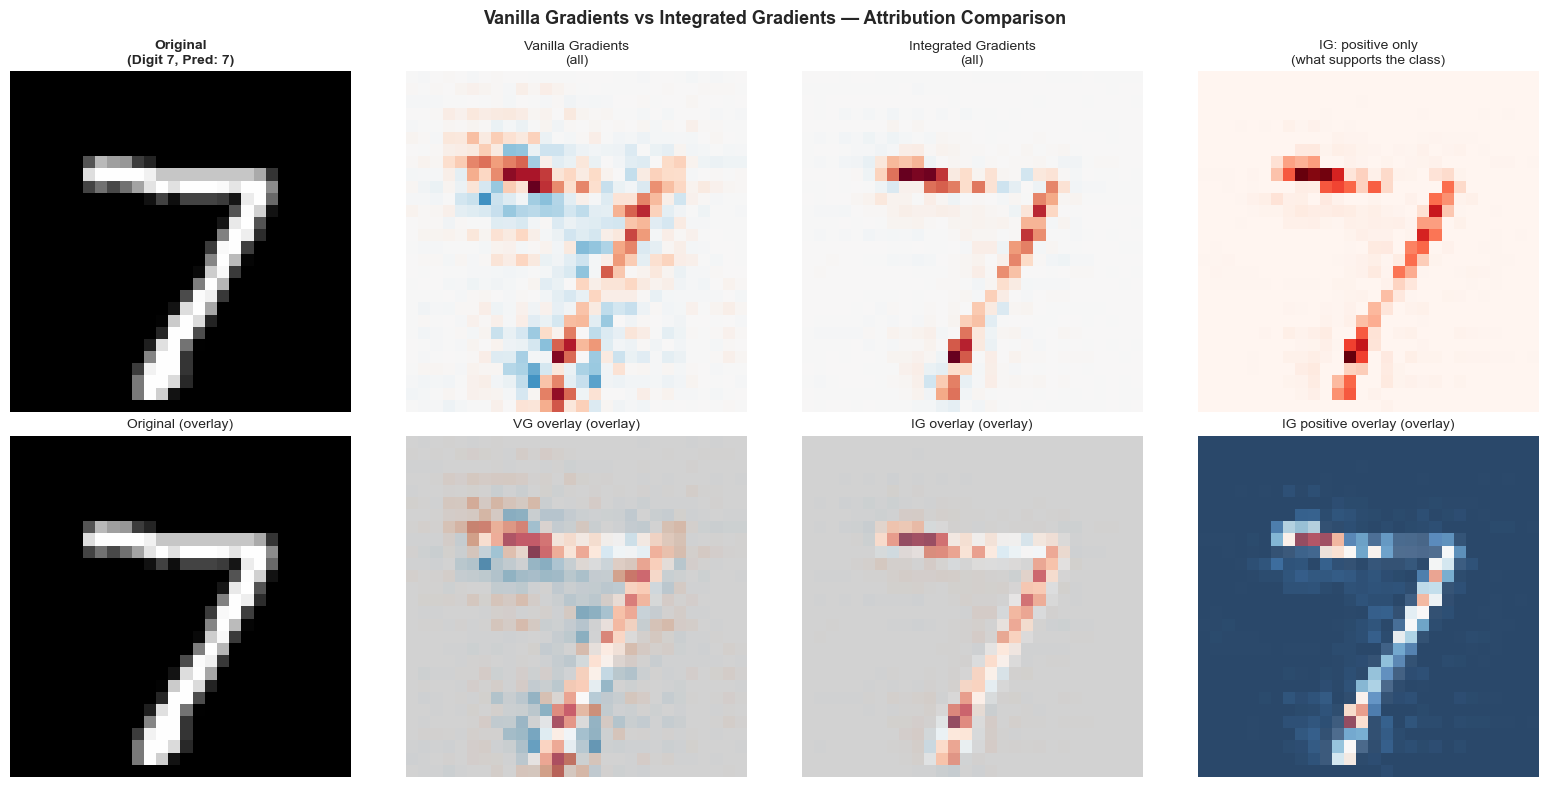

Integrated Gradients tend to be less noisy and more focused on the actual digit strokes.


In [21]:
# ── Side-by-side visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Normalize image for display
img_disp = (demo_img_np - demo_img_np.min()) / (demo_img_np.max() - demo_img_np.min() + 1e-8)

# Row 1: Full attribution (positive + negative)
titles_row1 = [
    f'Original\n(Digit {test_labels_all[digit_7_idx].item()}, Pred: {pred_cls_ig})',
    'Vanilla Gradients\n(all)',
    'Integrated Gradients\n(all)',
    'IG: positive only\n(what supports the class)'
]

# Original image
axes[0, 0].imshow(img_disp, cmap='gray')
axes[0, 0].set_title(titles_row1[0], fontsize=10, fontweight='bold')
axes[0, 0].axis('off')

# Vanilla gradients (all)
vg_display = vg if vg.ndim == 2 else vg.mean(0)
vmax = np.abs(vg_display).max()
axes[0, 1].imshow(vg_display, cmap=CMAP, vmin=-vmax, vmax=vmax)
axes[0, 1].set_title(titles_row1[1], fontsize=10)
axes[0, 1].axis('off')

# Integrated Gradients (all)
ig_display = ig_black if ig_black.ndim == 2 else ig_black.mean(0)
vmax_ig = np.abs(ig_display).max()
axes[0, 2].imshow(ig_display, cmap=CMAP, vmin=-vmax_ig, vmax=vmax_ig)
axes[0, 2].set_title(titles_row1[2], fontsize=10)
axes[0, 2].axis('off')

# IG positive only
ig_pos = np.maximum(ig_display, 0)
axes[0, 3].imshow(ig_pos, cmap='Reds')
axes[0, 3].set_title(titles_row1[3], fontsize=10)
axes[0, 3].axis('off')

# Row 2: Overlaid on image
for col_i, (attr, title) in enumerate([
    (img_disp, 'Original'),
    (vg_display, 'VG overlay'),
    (ig_display, 'IG overlay'),
    (ig_pos, 'IG positive overlay')
]):
    axes[1, col_i].imshow(img_disp, cmap='gray', alpha=0.5)
    if col_i == 0:
        axes[1, col_i].imshow(img_disp, cmap='gray')
    else:
        vmax_plot = np.abs(attr).max() + 1e-8
        axes[1, col_i].imshow(attr, cmap=CMAP, alpha=0.7,
                               vmin=-vmax_plot if col_i < 3 else 0, vmax=vmax_plot)
    axes[1, col_i].set_title(f'{title} (overlay)', fontsize=10)
    axes[1, col_i].axis('off')

fig.suptitle('Vanilla Gradients vs Integrated Gradients — Attribution Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Integrated Gradients tend to be less noisy and more focused on the actual digit strokes.')

## 🏋️ Exercise

1. **Baseline comparison**: Compute Integrated Gradients with three different baselines and compare:
   - (a) All zeros (black image) — the default
   - (b) All 0.5 (grey image)
   - (c) Random noise (`torch.randn_like(demo_img) * 0.1`)
   
   How do the attributions change? Which baseline produces the most interpretable result? Which feels most *fair* (i.e., the baseline represents "no information")?

2. **Completeness check**: Verify that IG satisfies completeness: sum the IG values for all pixels and compare to `F(input) - F(baseline)` for the target class. They should be approximately equal (up to Riemann sum error with 50 steps).

3. **Step count sensitivity**: Run IG with 10, 50, and 200 steps. How much do the attributions change? Is 50 steps sufficient?

```python
# Starter: three baselines
baseline_grey   = torch.ones_like(demo_img) * 0.5
baseline_noise  = torch.randn_like(demo_img) * 0.1

ig_grey,  _ = integrated_gradients(model, demo_img, baseline=baseline_grey,  n_steps=50)
ig_noise, _ = integrated_gradients(model, demo_img, baseline=baseline_noise, n_steps=50)

# Completeness check
model.eval()
with torch.no_grad():
    f_input    = torch.softmax(model(demo_img), dim=1)[0, pred_cls_ig].item()
    f_baseline = torch.softmax(model(baseline_black.to(device)), dim=1)[0, pred_cls_ig].item()
print(f'F(input) - F(baseline) = {f_input - f_baseline:.4f}')
print(f'Sum of IG values       = {ig_black.sum():.4f}')  # should be close!
```

---
# Section 6 — Probing Classifiers: What Do Representations Encode?

## The Idea

We've been asking *which inputs matter* for a prediction. Now we ask a different question: **what abstract concepts does the network's internal representation encode?**

A **probing classifier** is a simple (usually linear) classifier trained on top of frozen intermediate representations. If a linear probe can predict some concept from a representation, it means that concept is **linearly encoded** in that representation.

**Examples in practice**:
- NLP: Can you linearly predict part-of-speech from BERT's layer 3? What about syntax trees from layer 8?
- Vision: Do early CNN layers encode edges? Do deeper layers encode object parts?

**Analogy**: The representation is like a filing cabinet. Probing tells you which drawers exist. If you can quickly find "even/odd" in one search, that property is well-organized in the filing system.

> **💡 Key Insight**: High probe accuracy → the concept is linearly decodable from the representation. Low probe accuracy → the concept is either not represented, or encoded in a non-linear way (a non-linear probe would do better).

> **⚠️ Watch Out**: Probing measures what *can* be decoded — not necessarily what the model *uses* for its predictions. A representation might encode many concepts, but only use a few of them.


In [22]:
# ── Extract penultimate layer (128-dim) representations ────────────────────

def extract_representations(model, loader, device, layer='fc1'):
    """
    Extract activations from the penultimate fully connected layer.
    Returns:
        reps: (N, 128) numpy array
        labels: (N,) numpy array
    """
    model.eval()
    reps_list = []
    labels_list = []
    
    # Hook to capture fc1 output
    captured = {}
    def fc1_hook(module, input, output):
        captured['rep'] = F.relu(output).detach().cpu()  # apply ReLU as in forward pass
    
    hook = model.fc1.register_forward_hook(fc1_hook)
    
    with torch.no_grad():
        for imgs, lbls in loader:
            _ = model(imgs.to(device))        # trigger forward pass
            reps_list.append(captured['rep'])  # save captured activation
            labels_list.append(lbls)
    
    hook.remove()
    
    reps   = torch.cat(reps_list, dim=0).numpy()
    labels = torch.cat(labels_list, dim=0).numpy()
    return reps, labels

print('Extracting 128-dim representations from MNIST test set...')
reps_test, labels_test = extract_representations(model, test_loader, device)
print(f'Representations shape: {reps_test.shape}')  # (10000, 128)
print(f'Labels shape: {labels_test.shape}')

Extracting 128-dim representations from MNIST test set...
Representations shape: (10000, 128)
Labels shape: (10000,)


In [23]:
# ── Define probe tasks ─────────────────────────────────────────────────────
# We'll probe for three binary properties of digits:

def make_probe_labels(digit_labels):
    """Create binary probe labels for three tasks."""
    # Task A: Is the digit even? (0,2,4,6,8 = 1; 1,3,5,7,9 = 0)
    y_even = (digit_labels % 2 == 0).astype(int)
    
    # Task B: Is the digit >= 5? (5,6,7,8,9 = 1; 0,1,2,3,4 = 0)
    y_geq5 = (digit_labels >= 5).astype(int)
    
    # Task C: Does the digit have a closed loop? (0,1,8 = 1; others = 0)
    # (0 has one loop, 8 has two, 1 has none actually - but stylistically)
    # Let's use digits with clear loops: 0, 6, 8, 9
    y_loop = np.isin(digit_labels, [0, 6, 8, 9]).astype(int)
    
    return y_even, y_geq5, y_loop

y_even_test, y_geq5_test, y_loop_test = make_probe_labels(labels_test)

print('Probe tasks defined:')
print(f'  Task A (even):   {y_even_test.sum()} positive / {len(y_even_test)} total')
print(f'  Task B (>= 5):   {y_geq5_test.sum()} positive / {len(y_geq5_test)} total')
print(f'  Task C (loop):   {y_loop_test.sum()} positive / {len(y_loop_test)} total')

Probe tasks defined:
  Task A (even):   4926 positive / 10000 total
  Task B (>= 5):   4861 positive / 10000 total
  Task C (loop):   3921 positive / 10000 total


In [24]:
# ── Train linear probes ────────────────────────────────────────────────────
# Extract training set representations too
print('Extracting train representations...')
reps_train, labels_train = extract_representations(model, train_loader, device)
y_even_train, y_geq5_train, y_loop_train = make_probe_labels(labels_train)
print(f'Train reps shape: {reps_train.shape}')

# Baseline: random linear classifier (trained on random labels)
np.random.seed(0)
random_labels_train = np.random.randint(0, 2, len(labels_train))
random_labels_test  = np.random.randint(0, 2, len(labels_test))

tasks = [
    ('A: Even digit?',       y_even_train,    y_even_test),
    ('B: Digit >= 5?',       y_geq5_train,    y_geq5_test),
    ('C: Has loop (0,6,8,9)?', y_loop_train,  y_loop_test),
    ('Baseline (random)',    random_labels_train, random_labels_test),
]

results = {}
print('\nLinear Probe Results:')
print('-' * 50)

from sklearn.linear_model import LogisticRegression as LR

for task_name, y_tr, y_te in tasks:
    probe = LR(max_iter=500, C=1.0, random_state=42)
    probe.fit(reps_train, y_tr)
    acc_train = accuracy_score(y_tr, probe.predict(reps_train))
    acc_test  = accuracy_score(y_te, probe.predict(reps_test))
    results[task_name] = {'train': acc_train, 'test': acc_test}
    print(f'{task_name:30s} | Train: {acc_train:.4f} | Test: {acc_test:.4f}')

print('-' * 50)

Extracting train representations...
Train reps shape: (60000, 128)

Linear Probe Results:
--------------------------------------------------
A: Even digit?                 | Train: 0.9906 | Test: 0.9910
B: Digit >= 5?                 | Train: 0.9809 | Test: 0.9799
C: Has loop (0,6,8,9)?         | Train: 0.9895 | Test: 0.9873
Baseline (random)              | Train: 0.5150 | Test: 0.5026
--------------------------------------------------


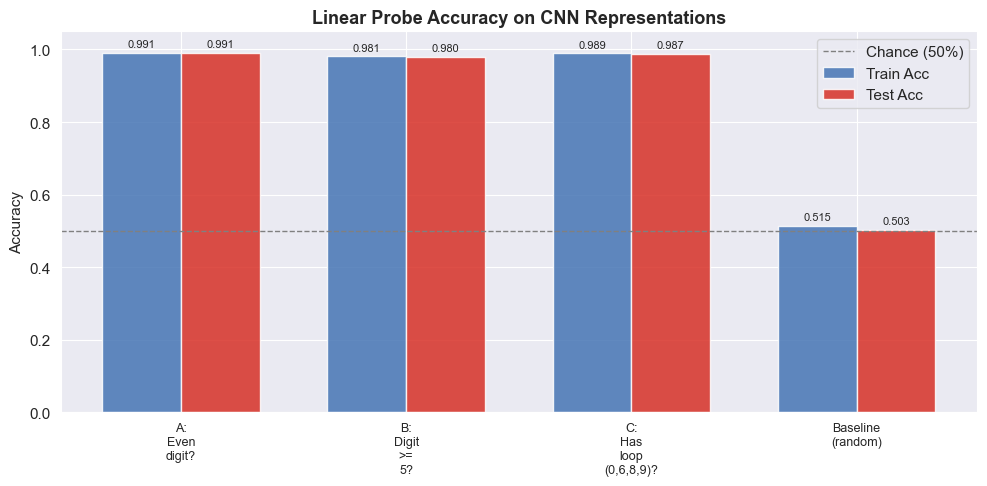

In [25]:
# ── Visualize probe results ────────────────────────────────────────────────
task_names = list(results.keys())
train_accs = [results[t]['train'] for t in task_names]
test_accs  = [results[t]['test']  for t in task_names]

x = np.arange(len(task_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, train_accs, width, label='Train Acc', color='#4575b4', alpha=0.85)
bars2 = ax.bar(x + width/2, test_accs,  width, label='Test Acc',  color='#d73027', alpha=0.85)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance (50%)')
ax.set_xticks(x)
ax.set_xticklabels([t.replace(' ', '\n') for t in task_names], fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Linear Probe Accuracy on CNN Representations', fontweight='bold', fontsize=13)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

Running t-SNE on test representations (this takes ~30 seconds)...
t-SNE done. Shape: (2000, 2)


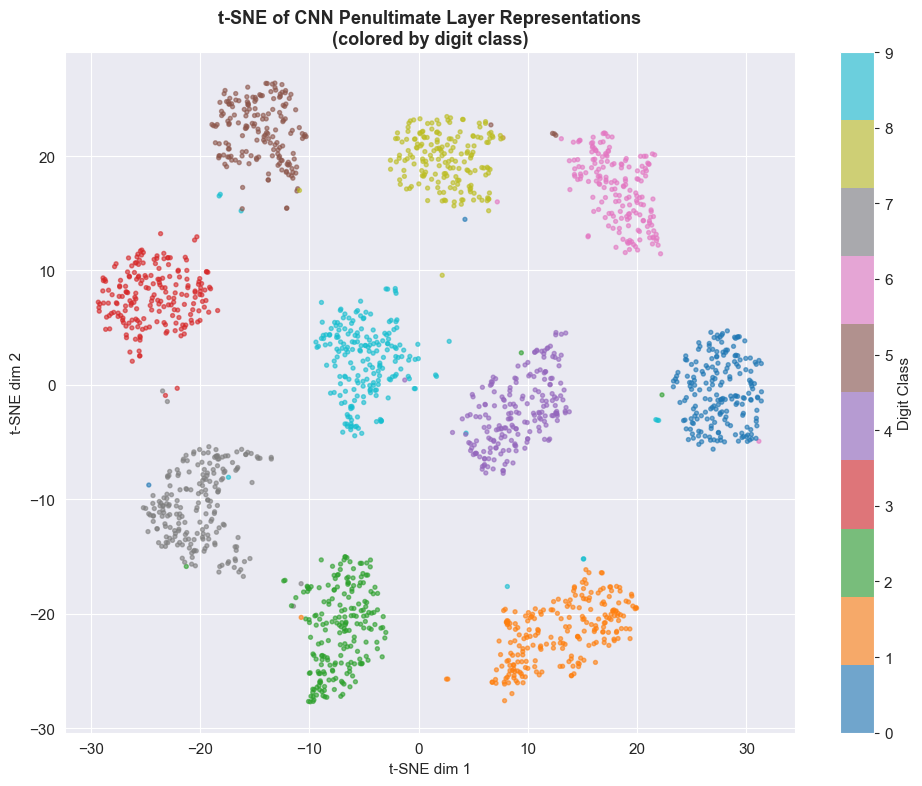

Well-separated clusters = the representation has learned class structure.


In [26]:
# ── t-SNE visualization of representations ─────────────────────────────────
print('Running t-SNE on test representations (this takes ~30 seconds)...')

# Use a subset for speed
n_tsne = 2000
idx_tsne = np.random.choice(len(reps_test), n_tsne, replace=False)
reps_sub   = reps_test[idx_tsne]
labels_sub = labels_test[idx_tsne]

tsne = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=500)  # n_iter → max_iter in sklearn 1.2+
reps_2d = tsne.fit_transform(reps_sub)

print(f't-SNE done. Shape: {reps_2d.shape}')

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(reps_2d[:, 0], reps_2d[:, 1], c=labels_sub,
                     cmap='tab10', alpha=0.6, s=8)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label('Digit Class', fontsize=11)
ax.set_title('t-SNE of CNN Penultimate Layer Representations\n(colored by digit class)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()
print('Well-separated clusters = the representation has learned class structure.')

## 🏋️ Exercise

1. **Nonlinear probes**: For each of the three probe tasks, train a small MLP probe (1 hidden layer, 32 units) instead of logistic regression. Does it do better? If yes, what does that tell you — is the concept encoded but not linearly, or is the linear probe just underpowered?

2. **Layer comparison**: Extract representations from `model.conv2` (after pooling) instead of `model.fc1`. How do the probe accuracies change? Do earlier representations encode these properties as well?

3. **t-SNE coloring**: Re-plot the t-SNE but color by *even/odd* instead of digit class. Can you visually see whether even and odd digits form separate clusters?

```python
# Starter: MLP probe
from sklearn.neural_network import MLPClassifier

mlp_probe = MLPClassifier(hidden_layer_sizes=(32,), max_iter=200, random_state=42)
mlp_probe.fit(reps_train, y_even_train)
mlp_acc_train = accuracy_score(y_even_train, mlp_probe.predict(reps_train))
mlp_acc_test  = accuracy_score(y_even_test,  mlp_probe.predict(reps_test))
print(f'MLP probe (even): Train={mlp_acc_train:.4f}, Test={mlp_acc_test:.4f}')

# Compare to linear probe
print(f'Linear probe (even): Test={results["A: Even digit?"]["test"]:.4f}')
```

---
# Section 7 — Attention: A Window Into Transformers

## What Is Attention?

The Transformer architecture (Vaswani et al. 2017, "Attention Is All You Need") revolutionized deep learning. Its core mechanism — **self-attention** — is one of the more interpretable components in modern neural networks, because it explicitly computes *routing weights* between tokens.

**Intuition**: When processing a sentence, attention allows the model to selectively focus on other tokens when computing each token's representation. For example, to understand the word "it" in "The animal didn't cross the street because it was too tired," the model might attend heavily to "animal."

## The Math (Simplified)

Given a sequence of token embeddings (each a vector), self-attention computes three projections:

- **Query (Q)**: "What am I looking for?"
- **Key (K)**: "What do I offer to others?"
- **Value (V)**: "What information do I carry?"

The attention weights are:
$$A = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)$$

And the output is: $\text{Attention}(Q, K, V) = A \cdot V$

The attention matrix `A` is directly visualizable — it tells you how much each token attends to each other token.

> **💡 Key Insight**: Attention weights are *not* a perfect explanation of what the model uses. Research (Jain & Wallace 2019, Wiegreffe & Pinter 2019) has shown that attention weights can disagree with gradient-based explanations. Still, they're a useful window into model behavior.

> **⚠️ Watch Out**: In multi-head attention, each head learns different patterns. Averaging across heads can obscure interpretable structure. Always look at individual heads.


In [27]:
# ── Minimal Single-Head Self-Attention from Scratch ────────────────────────

class SingleHeadSelfAttention(nn.Module):
    """
    Minimal implementation of single-head self-attention.
    
    Given sequence X of shape (seq_len, d_model):
    1. Project to Q, K, V using learned weight matrices
    2. Compute attention scores: Q @ K.T / sqrt(d_k)
    3. Apply softmax to get attention weights
    4. Output = attention_weights @ V
    """
    def __init__(self, d_model=16, d_k=8):
        super().__init__()
        self.d_k = d_k
        # Weight matrices for Q, K, V projections
        self.W_Q = nn.Linear(d_model, d_k, bias=False)
        self.W_K = nn.Linear(d_model, d_k, bias=False)
        self.W_V = nn.Linear(d_model, d_k, bias=False)
    
    def forward(self, X):
        """
        Args:
            X: (seq_len, d_model) — sequence of token embeddings
        Returns:
            output: (seq_len, d_k) — attended representations
            attn_weights: (seq_len, seq_len) — attention weight matrix
        """
        Q = self.W_Q(X)  # (seq_len, d_k)
        K = self.W_K(X)  # (seq_len, d_k)
        V = self.W_V(X)  # (seq_len, d_k)
        
        # Scaled dot-product attention
        scores = (Q @ K.T) / (self.d_k ** 0.5)   # (seq_len, seq_len)
        attn_weights = F.softmax(scores, dim=-1)   # (seq_len, seq_len)
        
        output = attn_weights @ V                  # (seq_len, d_k)
        return output, attn_weights

print('SingleHeadSelfAttention defined.')
print('Architecture: X -> (W_Q, W_K, W_V) -> Q, K, V -> softmax(QK^T / sqrt(d_k)) @ V')

SingleHeadSelfAttention defined.
Architecture: X -> (W_Q, W_K, W_V) -> Q, K, V -> softmax(QK^T / sqrt(d_k)) @ V


Tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat']
Attention weights shape: (6, 6)
Row sums (should be ~1.0): [1. 1. 1. 1. 1. 1.]


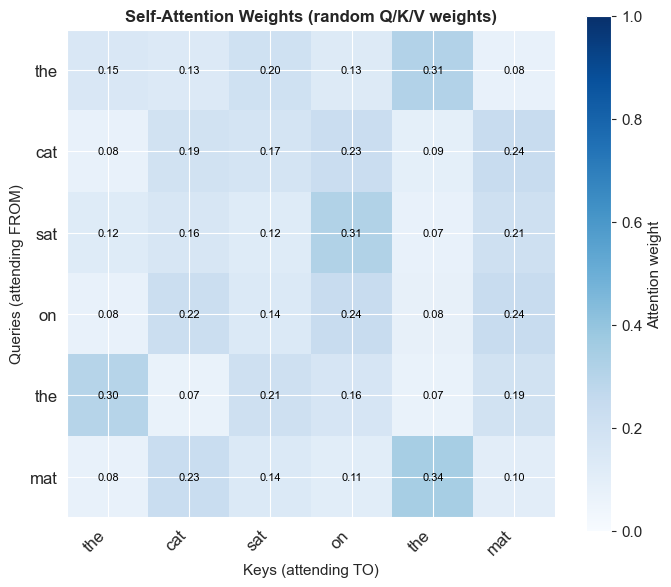

Row i, column j: how much does token i attend to token j?


In [28]:
# ── Visualize attention on a toy sentence ─────────────────────────────────
torch.manual_seed(42)

# Tokenize at character level for simplicity
sentence = "the cat sat on the mat"
tokens = sentence.split()  # word-level tokens
seq_len = len(tokens)
d_model = 16

# Create random embeddings for each token (normally these would be learned)
np.random.seed(42)
token_embeddings = torch.randn(seq_len, d_model)  # (6, 16)

# Initialize attention module
attn = SingleHeadSelfAttention(d_model=d_model, d_k=8)

# Forward pass
with torch.no_grad():
    output, attn_weights = attn(token_embeddings)

attn_matrix = attn_weights.numpy()  # (6, 6)

print(f'Tokens: {tokens}')
print(f'Attention weights shape: {attn_matrix.shape}')
print(f'Row sums (should be ~1.0): {attn_matrix.sum(axis=1).round(4)}')

# Plot attention heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(attn_matrix, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(seq_len))
ax.set_yticks(range(seq_len))
ax.set_xticklabels(tokens, fontsize=12, rotation=45, ha='right')
ax.set_yticklabels(tokens, fontsize=12)
ax.set_xlabel('Keys (attending TO)', fontsize=11)
ax.set_ylabel('Queries (attending FROM)', fontsize=11)
ax.set_title('Self-Attention Weights (random Q/K/V weights)', fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label='Attention weight')
# Annotate cells
for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f'{attn_matrix[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if attn_matrix[i,j] > 0.5 else 'black')
plt.tight_layout()
plt.show()
print('Row i, column j: how much does token i attend to token j?')

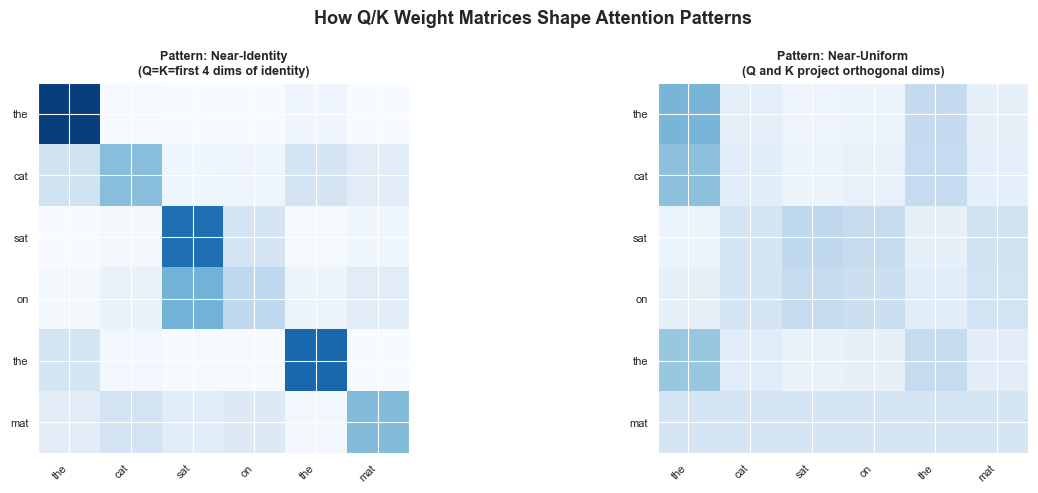

Key takeaway: attention patterns are fully controlled by Q and K matrices.
Large Q*K^T scores -> concentrated attention; small scores -> diffuse/uniform attention.


In [29]:
# ── How attention patterns change with different Q/K weights ───────────────
# Let's manually set Q and K weights to demonstrate interpretable patterns

def show_attention_pattern(W_Q_vals, W_K_vals, title, ax, tokens, token_embeddings):
    """Show attention for manually set Q/K weight matrices."""
    attn_custom = SingleHeadSelfAttention(d_model=d_model, d_k=4)
    with torch.no_grad():
        attn_custom.W_Q.weight.copy_(torch.tensor(W_Q_vals, dtype=torch.float32))
        attn_custom.W_K.weight.copy_(torch.tensor(W_K_vals, dtype=torch.float32))
        _, weights = attn_custom(token_embeddings)
    w = weights.numpy()
    im = ax.imshow(w, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, fontsize=8, rotation=45, ha='right')
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    return w

d_k_small = 4

# Pattern 1: Diagonal (attend to self) — identity-like Q and K
# If Q*K^T is dominated by diagonal, softmax produces near-identity attention
W_diag = np.eye(d_k_small, d_model)  # (4, 16)

# Pattern 2: Uniform attention — Q and K are orthogonal (scores all ~zero -> uniform softmax)
W_Q_uniform = np.zeros((d_k_small, d_model))
W_K_uniform = np.zeros((d_k_small, d_model))
W_Q_uniform[0, 0] = 1.0
W_K_uniform[0, 1] = 1.0  # Q picks dim 0, K picks dim 1 -> dot product ~0 for unrelated features

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

show_attention_pattern(W_diag, W_diag, 'Pattern: Near-Identity\n(Q=K=first 4 dims of identity)', 
                       axes[0], tokens, token_embeddings)
show_attention_pattern(W_Q_uniform, W_K_uniform, 'Pattern: Near-Uniform\n(Q and K project orthogonal dims)',
                       axes[1], tokens, token_embeddings)

fig.suptitle('How Q/K Weight Matrices Shape Attention Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key takeaway: attention patterns are fully controlled by Q and K matrices.')
print('Large Q*K^T scores -> concentrated attention; small scores -> diffuse/uniform attention.')

In [30]:
# ── Attention Entropy: measuring focus ─────────────────────────────────────
# Entropy of attention weights: high entropy = diffuse attention, low = focused

def attention_entropy(attn_weights):
    """Compute Shannon entropy of attention weights per query position."""
    # attn_weights: (seq_len, seq_len)
    eps = 1e-9
    entropy = -(attn_weights * np.log(attn_weights + eps)).sum(axis=-1)
    return entropy  # (seq_len,)

# Compare entropy for random vs structured attention
with torch.no_grad():
    _, attn_random  = attn(token_embeddings)  # random weights (from above)

attn_random_np = attn_random.numpy()
ent_random = attention_entropy(attn_random_np)

print('Attention entropy per token position (random Q/K/V):')
for tok, ent in zip(tokens, ent_random):
    bar = '|' * int(ent * 10)
    print(f'  {tok:6s}: {ent:.3f} {bar}')
print(f'\nMax possible entropy (uniform): {np.log(seq_len):.3f}')
print(f'Min possible entropy (peaked):  0.000')
print('\nLow entropy = focused attention (knows exactly where to look)')
print('High entropy = diffuse attention (attending to everything equally)')

Attention entropy per token position (random Q/K/V):
  the   : 1.701 |||||||||||||||||
  cat   : 1.714 |||||||||||||||||
  sat   : 1.690 ||||||||||||||||
  on    : 1.696 ||||||||||||||||
  the   : 1.671 ||||||||||||||||
  mat   : 1.649 ||||||||||||||||

Max possible entropy (uniform): 1.792
Min possible entropy (peaked):  0.000

Low entropy = focused attention (knows exactly where to look)
High entropy = diffuse attention (attending to everything equally)


In [31]:
# ── HuggingFace transformer attention (stub with try/except) ──────────────
# This cell shows how you'd visualize real transformer attention in practice.
# It requires the 'transformers' package. If not installed, it gracefully skips.

try:
    from transformers import AutoTokenizer, AutoModel
    import warnings
    warnings.filterwarnings('ignore')
    
    tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
    bert = AutoModel.from_pretrained('bert-base-uncased', output_attentions=True)
    bert.eval()
    
    text = "The animal didn't cross the street because it was too tired."
    inputs = tokenizer(text, return_tensors='pt')
    tokens_hf = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    
    with torch.no_grad():
        outputs = bert(**inputs)
    
    # outputs.attentions: tuple of (batch, heads, seq, seq) per layer
    # Let's look at layer 6, head 0
    layer_idx, head_idx = 5, 0
    attn_hf = outputs.attentions[layer_idx][0, head_idx].numpy()  # (seq_len, seq_len)
    seq_len_hf = len(tokens_hf)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(attn_hf, cmap='Blues')
    ax.set_xticks(range(seq_len_hf))
    ax.set_yticks(range(seq_len_hf))
    ax.set_xticklabels(tokens_hf, rotation=90, fontsize=9)
    ax.set_yticklabels(tokens_hf, fontsize=9)
    ax.set_title(f'BERT Attention — Layer {layer_idx+1}, Head {head_idx+1}', fontweight='bold')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
    print(f'Sentence: "{text}"')
    print(f'Showing Layer {layer_idx+1}, Head {head_idx+1} attention.')
    print('Notice how "it" might attend strongly to "animal" — coreference resolution!')

except ImportError:
    print('transformers package not installed. Skipping HuggingFace demo.')
    print('To run this cell: pip install transformers')
    print()
    print('In a real BERT model, you would see:')
    print('  - Early layers: local attention (adjacent tokens)')
    print('  - Middle layers: syntactic patterns (subject-verb, noun-adjective)')
    print('  - Late layers: semantic/task-specific patterns')

transformers package not installed. Skipping HuggingFace demo.
To run this cell: pip install transformers

In a real BERT model, you would see:
  - Early layers: local attention (adjacent tokens)
  - Middle layers: syntactic patterns (subject-verb, noun-adjective)
  - Late layers: semantic/task-specific patterns


## 🏋️ Exercise

1. **CLS token attention**: Transformer models often use a special `[CLS]` token whose representation is used for classification. Ideally, it attends broadly to all tokens. Manually set Q and K weight matrices so that position 0 (like a `[CLS]` token) has high attention weights toward *all* other positions. Hint: you want the dot product between `Q[0]` and `K[j]` to be large and equal for all `j`. What Q/K structure achieves this?

2. **Attention entropy analysis**: Compute the entropy of attention weights for each row in the attention matrix. A focused head (low entropy) "knows what it's looking for." A diffuse head (high entropy) attends uniformly. Design Q/K weights that minimize the entropy of the first row's attention.

3. **Multi-head extension**: Extend `SingleHeadSelfAttention` to a `MultiHeadSelfAttention` module with 4 heads. After a random initialization, visualize all 4 attention patterns side by side. Do they differ from each other?

```python
# Starter: CLS-like attention
# For CLS to attend to everything: we want Q[0] @ K[j]^T to be constant for all j.
# One way: set W_Q to zero (Q = 0 for all tokens), so scores are all 0 -> uniform softmax
# But that's boring. A better way:
# Set W_Q[0] = some vector v, and W_K = v for all tokens (project all tokens to same direction)
# Then Q[0] @ K[j] = v @ v = ||v||^2 for all j -> uniform!

W_Q_cls = np.zeros((d_k_small, d_model))
W_K_cls = np.zeros((d_k_small, d_model))
v = np.random.randn(d_model)
v = v / np.linalg.norm(v)  # unit vector
W_Q_cls[0] = v   # first query dimension = v
W_K_cls[0] = v   # all keys project onto v -> Q[i] @ K[j] same for all j
# ... visualize and check entropy of first row
```

---
# Final Challenge — The Shortcut Hunter

## Your Mission

You are given a **black-box RandomForest** trained on a dataset. Your job is to investigate whether the model learned something real, or whether it's exploiting a hidden shortcut.

**The dataset has a hidden spurious feature. Find it.**

Work through the following steps using the tools you've learned in this notebook:

---

### Step 1: Use SHAP to find the most important feature
Apply `shap.TreeExplainer` to the black-box model. Which feature has the highest mean |SHAP| value on the test set?

### Step 2: Use permutation importance to double-check
Apply `sklearn.inspection.permutation_importance` on both train and test sets. Does the ranking agree with SHAP? Is there a suspicious gap between train and test importance for any feature?

### Step 3: Is it a real signal or a shortcut?
Take the top-ranked feature. Investigate:
- Train a new model *with* that feature. What's train and test accuracy?
- Train a new model *without* that feature. What changes?
- Does removing it *hurt* test performance (real signal) or *not change it much* (shortcut)?

### Step 4: Retrain an honest model
If the top feature is a shortcut, retrain the model without it. Compare SHAP explanations before and after. Is the new model's reasoning more trustworthy?

> **💡 Hint**: A shortcut feature typically shows high training importance but low test importance (the gap you saw in Section 1). Real signal features maintain their importance across splits.


In [32]:
# ── Final Challenge: Setup — dataset and black-box model ───────────────────
np.random.seed(99)  # different seed so it's a fresh mystery

N_ch = 2000

# True labels
y_ch = np.random.randint(0, 2, size=N_ch)

# Feature engineering:
# 5 real signal features (genuinely predictive, varying strength)
X_ch_real = np.column_stack([
    np.random.randn(N_ch) + y_ch * 1.2,        # feature 0: strong signal
    np.random.randn(N_ch) + y_ch * 0.8,        # feature 1: medium signal
    np.random.randn(N_ch) + y_ch * 0.4,        # feature 2: weak signal
    np.random.randn(N_ch) * 2 + y_ch * 0.5,   # feature 3: noisy weak signal
    np.random.randn(N_ch) + y_ch * 0.6,        # feature 4: medium signal
])

# 3 pure noise features
X_ch_noise = np.random.randn(N_ch, 3)          # features 5,6,7

# 1 spurious feature: 97% correlated with y in train, random in test
spurious_ch_full = y_ch.astype(float) + np.random.randn(N_ch) * 0.05  # ~97% corr
spurious_ch_test = np.random.randn(N_ch)  # breaks at test time

# Assemble
X_ch_train_full = np.column_stack([X_ch_real, X_ch_noise, spurious_ch_full])
X_ch_test_full  = np.column_stack([X_ch_real, X_ch_noise, spurious_ch_test])

# Split
idx_ch = np.arange(N_ch)
np.random.shuffle(idx_ch)
tr_idx, te_idx = idx_ch[:1400], idx_ch[1400:]

X_ch_tr = X_ch_train_full[tr_idx]
X_ch_te = X_ch_test_full[te_idx]
y_ch_tr = y_ch[tr_idx]
y_ch_te = y_ch[te_idx]

challenge_feature_names = [
    'feature_A', 'feature_B', 'feature_C', 'feature_D', 'feature_E',  # real signals
    'feature_F', 'feature_G', 'feature_H',                             # noise
    'feature_X'                                                         # the hidden shortcut
]

# Train the black-box model (you don't know its internals)
blackbox_rf = RandomForestClassifier(n_estimators=150, max_depth=None, random_state=42)
blackbox_rf.fit(X_ch_tr, y_ch_tr)

bb_train_acc = accuracy_score(y_ch_tr, blackbox_rf.predict(X_ch_tr))
bb_test_acc  = accuracy_score(y_ch_te, blackbox_rf.predict(X_ch_te))

print('Black-box model trained. You do not know its internals.')
print(f'Train accuracy: {bb_train_acc:.4f}')
print(f'Test accuracy:  {bb_test_acc:.4f}')
print(f'Features: {challenge_feature_names}')
print('\nYour mission: find the hidden shortcut using SHAP and permutation importance.')
print('One of these features is only useful in training, not in the real world!')

Black-box model trained. You do not know its internals.
Train accuracy: 1.0000
Test accuracy:  0.5067
Features: ['feature_A', 'feature_B', 'feature_C', 'feature_D', 'feature_E', 'feature_F', 'feature_G', 'feature_H', 'feature_X']

Your mission: find the hidden shortcut using SHAP and permutation importance.
One of these features is only useful in training, not in the real world!


SHAP Feature Importance Ranking (mean |SHAP| on test set):
feature_X    0.477783
feature_A    0.052738
feature_B    0.027381
feature_E    0.011021
feature_C    0.006036
feature_D    0.004377
feature_H    0.002016
feature_G    0.001422
feature_F    0.001167

Top feature: feature_X


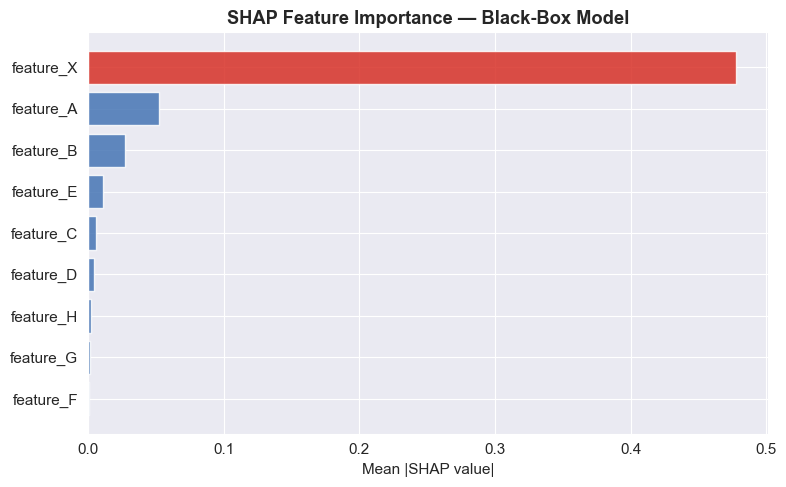


Suspect the top feature. Now check if this holds on training data too...


In [33]:
# ── Step 1: SHAP analysis ─────────────────────────────────────────────────
# YOUR TASK: Apply SHAP TreeExplainer to find feature importances
# Hint: follow the pattern from Section 3

explainer_ch = shap.TreeExplainer(blackbox_rf)
shap_vals_ch = explainer_ch(X_ch_te)

# Mean |SHAP| per feature (averaged over both classes for binary classification)
if len(shap_vals_ch.shape) == 3:  # (n_samples, n_features, n_classes)
    mean_abs_shap_ch = np.abs(shap_vals_ch.values).mean(axis=(0, 2))
else:
    mean_abs_shap_ch = np.abs(shap_vals_ch.values).mean(axis=0)

shap_ranking = pd.Series(mean_abs_shap_ch, index=challenge_feature_names).sort_values(ascending=False)

print('SHAP Feature Importance Ranking (mean |SHAP| on test set):')
print(shap_ranking.to_string())
print(f'\nTop feature: {shap_ranking.index[0]}')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d73027' if n == shap_ranking.index[0] else '#4575b4' for n in shap_ranking.index]
ax.barh(shap_ranking.index[::-1], shap_ranking.values[::-1], color=colors[::-1], alpha=0.85)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Feature Importance — Black-Box Model', fontweight='bold')
plt.tight_layout()
plt.show()
print('\nSuspect the top feature. Now check if this holds on training data too...')

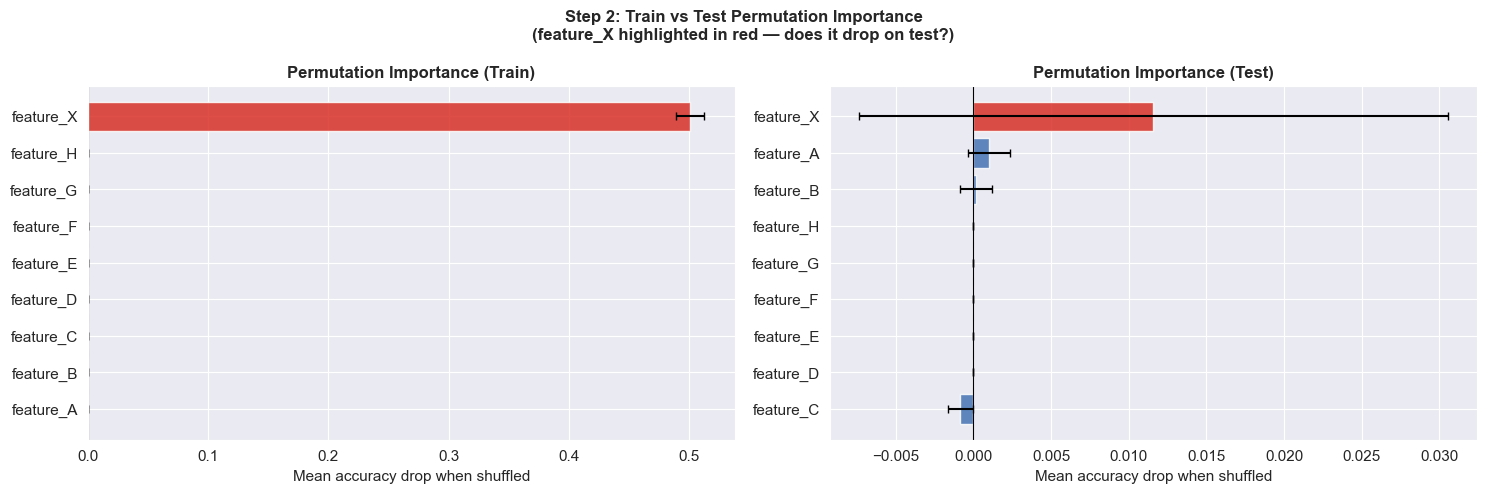


Importance gap (train - test) for each feature:
  feature_A   : train=0.0000, test=0.0010, gap=-0.0010
  feature_B   : train=0.0000, test=0.0002, gap=-0.0002
  feature_C   : train=0.0000, test=-0.0008, gap=+0.0008
  feature_D   : train=0.0000, test=0.0000, gap=+0.0000
  feature_E   : train=0.0000, test=0.0000, gap=+0.0000
  feature_F   : train=0.0000, test=0.0000, gap=+0.0000
  feature_G   : train=0.0000, test=0.0000, gap=+0.0000
  feature_H   : train=0.0000, test=0.0000, gap=+0.0000
  feature_X   : train=0.5006, test=0.0116, gap=+0.4891  <-- SUSPICIOUS!


In [34]:
# ── Step 2: Permutation importance — train vs test ─────────────────────────
perm_ch_train = permutation_importance(blackbox_rf, X_ch_tr, y_ch_tr, n_repeats=20, random_state=42)
perm_ch_test  = permutation_importance(blackbox_rf, X_ch_te, y_ch_te, n_repeats=20, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, perm, split in zip(axes, [perm_ch_train, perm_ch_test], ['Train', 'Test']):
    means = perm.importances_mean
    stds  = perm.importances_std
    # Sort by mean importance
    order = np.argsort(means)
    feat_sorted = [challenge_feature_names[i] for i in order]
    colors = ['#d73027' if n == 'feature_X' else '#4575b4' for n in feat_sorted]
    ax.barh(feat_sorted, means[order], xerr=stds[order],
            color=colors, alpha=0.85, capsize=3)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Permutation Importance ({split})', fontweight='bold', fontsize=12)
    ax.set_xlabel('Mean accuracy drop when shuffled')

fig.suptitle('Step 2: Train vs Test Permutation Importance\n'
             '(feature_X highlighted in red — does it drop on test?)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the gap for each feature
print('\nImportance gap (train - test) for each feature:')
for i, name in enumerate(challenge_feature_names):
    gap = perm_ch_train.importances_mean[i] - perm_ch_test.importances_mean[i]
    flag = '  <-- SUSPICIOUS!' if abs(gap) > 0.05 else ''
    print(f'  {name:12s}: train={perm_ch_train.importances_mean[i]:.4f}, '
          f'test={perm_ch_test.importances_mean[i]:.4f}, gap={gap:+.4f}{flag}')

In [35]:
# ── Step 3: Investigate the shortcut — with vs without feature_X ──────────
feature_X_col = challenge_feature_names.index('feature_X')  # column index of suspect

# Model WITH feature_X (the original black-box)
acc_with_train = accuracy_score(y_ch_tr, blackbox_rf.predict(X_ch_tr))
acc_with_test  = accuracy_score(y_ch_te, blackbox_rf.predict(X_ch_te))

# Remove feature_X and retrain
cols_no_X = [i for i in range(len(challenge_feature_names)) if i != feature_X_col]
rf_no_X = RandomForestClassifier(n_estimators=150, random_state=42)
rf_no_X.fit(X_ch_tr[:, cols_no_X], y_ch_tr)
acc_no_X_train = accuracy_score(y_ch_tr, rf_no_X.predict(X_ch_tr[:, cols_no_X]))
acc_no_X_test  = accuracy_score(y_ch_te, rf_no_X.predict(X_ch_te[:, cols_no_X]))

print('Comparison: With feature_X vs Without feature_X')
print('-' * 55)
print(f"{'':30s} {'Train':>10} {'Test':>10}")
print(f"{'With feature_X (black-box)':30s} {acc_with_train:>10.4f} {acc_with_test:>10.4f}")
print(f"{'Without feature_X':30s} {acc_no_X_train:>10.4f} {acc_no_X_test:>10.4f}")
print('-' * 55)
print()

if acc_with_train > acc_no_X_train + 0.02:
    print('Training accuracy dropped when feature_X was removed.')
    print('This confirms the model was relying heavily on it during training.')

if abs(acc_with_test - acc_no_X_test) < 0.03:
    print('Test accuracy barely changed! feature_X was a SHORTCUT.')
    print('The model without the shortcut is more honest — it\'s forced to use real signals.')
elif acc_no_X_test < acc_with_test - 0.05:
    print('Test accuracy dropped significantly — feature_X might have real signal too.')
    print('Consider whether the feature could be legitimate or just happened to be predictive.')

Comparison: With feature_X vs Without feature_X
-------------------------------------------------------
                                    Train       Test
With feature_X (black-box)         1.0000     0.5067
Without feature_X                  1.0000     0.8067
-------------------------------------------------------



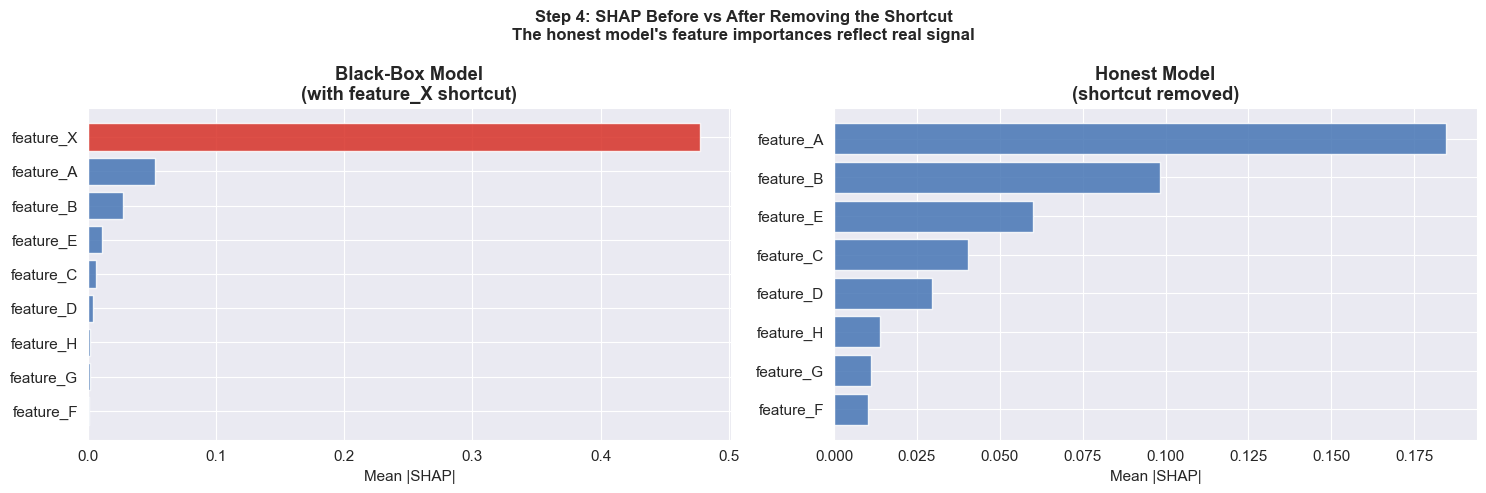


Conclusion:
  Top feature before: feature_X
  Top feature after:  feature_A

The honest model now emphasizes features with genuine predictive signal.
Its explanations can be trusted to reflect the true underlying patterns.


In [36]:
# ── Step 4: Compare SHAP before and after removing the shortcut ────────────
feat_names_no_X = [n for n in challenge_feature_names if n != 'feature_X']

# SHAP for the honest model (no feature_X)
explainer_honest = shap.TreeExplainer(rf_no_X)
shap_vals_honest = explainer_honest(X_ch_te[:, cols_no_X])

if len(shap_vals_honest.shape) == 3:
    mean_abs_honest = np.abs(shap_vals_honest.values).mean(axis=(0, 2))
else:
    mean_abs_honest = np.abs(shap_vals_honest.values).mean(axis=0)

shap_honest_ranking = pd.Series(mean_abs_honest, index=feat_names_no_X).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original black-box SHAP
axes[0].barh(shap_ranking.index[::-1], shap_ranking.values[::-1],
             color=['#d73027' if n == 'feature_X' else '#4575b4' for n in shap_ranking.index[::-1]],
             alpha=0.85)
axes[0].set_title('Black-Box Model\n(with feature_X shortcut)', fontweight='bold')
axes[0].set_xlabel('Mean |SHAP|')

# Honest model SHAP
axes[1].barh(shap_honest_ranking.index[::-1], shap_honest_ranking.values[::-1],
             color='#4575b4', alpha=0.85)
axes[1].set_title('Honest Model\n(shortcut removed)', fontweight='bold')
axes[1].set_xlabel('Mean |SHAP|')

fig.suptitle('Step 4: SHAP Before vs After Removing the Shortcut\n'
             'The honest model\'s feature importances reflect real signal',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nConclusion:')
print(f'  Top feature before: {shap_ranking.index[0]}')
print(f'  Top feature after:  {shap_honest_ranking.index[0]}')
print()
print('The honest model now emphasizes features with genuine predictive signal.')
print('Its explanations can be trusted to reflect the true underlying patterns.')

---
# Congratulations! You've completed the Interpretability Tour.

## What You've Learned

| Tool | What it Does | When to Use |
|---|---|---|
| **Permutation Importance** | Feature ranking by accuracy drop | Quick global importance on tabular data |
| **LIME** | Local linear approximation | Explaining individual predictions (any model) |
| **SHAP** | Shapley value attributions | Both local and global, principled decomposition |
| **Grad-CAM** | Spatial attention heatmap | CNNs: where did it look? |
| **Integrated Gradients** | Path-integral pixel attribution | CNNs/any differentiable model, pixel-level |
| **Probing** | Linear decoding of representations | What concepts are encoded in intermediate layers? |
| **Attention Visualization** | Weight matrix heatmaps | Transformers: routing patterns |

## Key Takeaways

> **High accuracy does not mean the model learned the right thing.** Always audit what features or pixels it relies on.

> **Local and global explanations can disagree.** LIME explains a single point; SHAP aggregates over the dataset. Both are useful.

> **The choice of baseline matters for gradient-based methods.** There is no universally correct choice — it depends on what question you're asking.

> **Interpretability is not a silver bullet.** These tools all have failure modes and should be used as evidence, not verdicts.

## Further Reading

- **LIME**: Ribeiro et al. (2016) — "Why Should I Trust You?"
- **SHAP**: Lundberg & Lee (2017) — "A Unified Approach to Interpreting Model Predictions"
- **Grad-CAM**: Selvaraju et al. (2017) — "Grad-CAM: Visual Explanations from Deep Networks"
- **Integrated Gradients**: Sundararajan et al. (2017) — "Axiomatic Attribution for Deep Networks"
- **Shortcut Learning**: Geirhos et al. (2020) — "Shortcut Learning in Deep Neural Networks"
- **Attention Faithfulness**: Jain & Wallace (2019) — "Attention is not Explanation"
- **Probing**: Conneau et al. (2018) — "What you can cram into a single vector"

---
*Happy interpreting!*